## 1st

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import RFECV

# For visualization
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Define paths for data loading
GUIDED_X_PATH = 'guided_dataset_X.npy'
GUIDED_Y_PATH = 'guided_dataset_y.npy'
GUIDED_TEST_X_PATH = 'guided_testset_X.npy'

In [22]:
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Custom transformer to extract time-domain features from EMG windows.
    Inherits from scikit-learn's BaseEstimator and TransformerMixin.
    """
    
    def __init__(self, feature_set='all', selected_features_indices=None):
        """
        Initialize the feature extractor.
        
        Parameters:
        -----------
        feature_set : str or list
            Specifies which features to extract. Options:
            - 'all': All implemented features
            - 'basic': Only MAV, RMS, and Variance (commonly used core features)
            - list of feature names: e.g., ['MAV', 'RMS', 'ZC']
        selected_features_indices : array-like, optional
            Indices of features to select after extraction. If None, all features are returned.
        """
        self.feature_set = feature_set
        self.selected_features_indices = selected_features_indices
        
        # Define all available features
        self.all_features = ['MAV', 'RMS', 'VAR', 'STD', 'ZC', 'MPR']
        
        # Define feature sets
        if self.feature_set == 'all':
            self.selected_features = self.all_features
            self.selected_electrodes = list(range(8))  # All 8 electrodes
        elif self.feature_set == 'basic':
            # MAV, RMS, VAR are selected as 'basic' because they're the most commonly used
            self.selected_features = ['MAV', 'RMS', 'VAR']
            self.selected_electrodes = list(range(8))  # All 8 electrodes
        elif isinstance(self.feature_set, list):
            self.selected_features = [f for f in self.feature_set if f in self.all_features]
            self.selected_electrodes = list(range(8))  # All 8 electrodes
        else:
            raise ValueError("feature_set must be 'all', 'basic', or a list of feature names")
    
    def fit(self, X, y=None):
        """Fit method (required for scikit-learn pipeline compatibility)."""
        return self
    
    def transform(self, X):
        """
        Extract features from EMG windows.
        
        Parameters:
        -----------
        X : numpy.ndarray
            Input data with shape (n_samples, n_channels, window_size)
            
        Returns:
        --------
        features : numpy.ndarray
            Extracted features with shape (n_samples, n_features)
        """
        n_samples, n_channels, window_size = X.shape
        
        # Regular feature extraction for all or custom feature sets
        n_features = len(self.selected_features) * len(self.selected_electrodes)
        features = np.zeros((n_samples, n_features))
        
        for i in range(n_samples):
            sample_features = self._extract_features_from_window(X[i])
            features[i] = sample_features
        
        # Apply feature selection if indices are provided
        if self.selected_features_indices is not None:
            features = features[:, self.selected_features_indices]
        
        return features
    
    def _extract_features_from_window(self, window):
        """Extract features from a single EMG window."""
        features = []
        
        for channel in self.selected_electrodes:
            channel_data = window[channel]
            channel_features = []
            
            # Mean Absolute Value (MAV)
            if 'MAV' in self.selected_features:
                mav = np.mean(np.abs(channel_data))
                channel_features.append(mav)
            
            # Root Mean Square (RMS)
            if 'RMS' in self.selected_features:
                rms = np.sqrt(np.mean(channel_data**2))
                channel_features.append(rms)
            
            # Variance (VAR)
            if 'VAR' in self.selected_features:
                var = np.var(channel_data)
                channel_features.append(var)
            
            # Standard Deviation (STD)
            if 'STD' in self.selected_features:
                std = np.std(channel_data)
                channel_features.append(std)
            
            # Zero Crossing (ZC)
            if 'ZC' in self.selected_features:
                zc = np.sum(np.diff(np.signbit(channel_data).astype(int)) != 0)
                channel_features.append(zc)
            
            # Myopulse Percentage Rate (MPR)
            if 'MPR' in self.selected_features:
                threshold = np.std(channel_data)
                mpr = np.mean(np.abs(channel_data) > threshold)
                channel_features.append(mpr)
            
            # Add all features for this channel
            features.extend(channel_features)
        
        return np.array(features)
    
    def get_feature_names(self):
        """Get the names of the features that will be extracted."""
        feature_names = []
        for channel in self.selected_electrodes:
            for feature in self.selected_features:
                feature_names.append(f'E{channel+1}_{feature}')
        
        # Apply feature selection if indices are provided
        if self.selected_features_indices is not None:
            feature_names = [feature_names[i] for i in self.selected_features_indices]
            
        return feature_names

In [23]:
def recommended_emg_filter(data, fs=1024):
    """
    Apply recommended filtering to EMG signals.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Input data with shape (session, electrode, time)
    fs : int
        Sampling frequency in Hz (default: 1024)
        
    Returns:
    --------
    filtered_data : numpy.ndarray
        Filtered data with same shape as input
    """
    n_sessions, n_electrodes, n_samples = data.shape
    filtered_data = np.zeros_like(data)
    
    # EMG typically contains frequencies between 20-500 Hz
    # A bandpass filter of 20-450 Hz is commonly used
    lowcut = 20  # High-pass to remove motion artifacts
    highcut = 450  # Low-pass to remove high frequency noise
    
    # Notch filter at 50Hz (or 60Hz for US) to remove power line interference
    notch_freq = 50
    quality_factor = 30  # Q factor determines notch width
    
    # Create bandpass filter
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b_band, a_band = butter(4, [low, high], btype='band')
    
    # Create notch filter
    b_notch, a_notch = iirnotch(notch_freq, quality_factor, fs)
    
    # Apply filters to each session and electrode
    for session in range(n_sessions):
        for electrode in range(n_electrodes):
            # First apply bandpass
            temp = filtfilt(b_band, a_band, data[session, electrode, :])
            # Then apply notch
            filtered_data[session, electrode, :] = filtfilt(b_notch, a_notch, temp)
    
    return filtered_data

def visualize_filtered_signals(original_data, filtered_data, session_id=0, electrode_id=0, time_segment=slice(0, 5000)):
    """
    Visualize the original and filtered EMG signals.
    """
    plt.figure(figsize=(15, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(original_data[session_id, electrode_id, time_segment])
    plt.title(f'Original EMG Signal - Session {session_id+1}, Electrode {electrode_id+1}')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.plot(filtered_data[session_id, electrode_id, time_segment])
    plt.title(f'Filtered EMG Signal - Session {session_id+1}, Electrode {electrode_id+1}')
    plt.xlabel('Time (samples)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def create_windows_with_overlap(data, window_size=500, overlap_percent=50):
    """
    Create overlapping windows from continuous EMG data with explicit verification
    of window positioning.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Input data with shape (session, electrode/joint, time)
    window_size : int
        Size of each window in samples (default: 500)
    overlap_percent : float
        Percentage of overlap between consecutive windows (0-100) (default: 50)
    
    Returns:
    --------
    windows : numpy.ndarray
        Windowed data with shape (n_windows_total, electrode/joint, window_size)
    window_indices : list of tuples
        List containing (session_idx, window_start_idx, window_end_idx) for each window
    """
    n_sessions, n_channels, n_samples = data.shape
    
    # Calculate step size based on overlap percentage
    step_size = int(window_size * (1 - overlap_percent/100))
    print(f"Window size: {window_size}, Overlap: {overlap_percent}%, Step size: {step_size}")
    
    windows = []
    window_indices = []
    
    # Process each session separately
    for session_idx in range(n_sessions):
        # Calculate how many windows we can extract from this session
        n_windows = 1 + (n_samples - window_size) // step_size
        
        for window_idx in range(n_windows):
            # Calculate start and end indices
            start_idx = window_idx * step_size
            end_idx = start_idx + window_size
            
            # Make sure we don't exceed the data length
            if end_idx <= n_samples:
                # Extract window for all channels
                window = data[session_idx, :, start_idx:end_idx]
                windows.append(window)
                window_indices.append((session_idx, start_idx, end_idx))
    
    # Convert list of windows to numpy array
    windows = np.array(windows)
    
    # Print out the first few window indices to verify correct overlap
    if len(window_indices) > 3:
        print("First few window indices to verify overlap:")
        for i in range(min(5, len(window_indices))):
            session, start, end = window_indices[i]
            print(f"Window {i+1}: Session {session+1}, Samples {start+1}-{end}")
    
    return windows, window_indices

def create_matching_windows(X_data, y_data, window_size=500, overlap_percent=50):
    """
    Create matching windowed datasets for both EMG (X) and joint angles (y).
    
    Parameters:
    -----------
    X_data : numpy.ndarray
        EMG data with shape (session, electrode, time)
    y_data : numpy.ndarray
        Joint angle data with shape (session, joint, time)
    window_size : int
        Size of each window in samples
    overlap_percent : float
        Percentage of overlap between consecutive windows (0-100)
    
    Returns:
    --------
    X_windows : numpy.ndarray
        Windowed EMG data with shape (n_windows, electrode, window_size)
    y_windows : numpy.ndarray
        Windowed joint angle data with shape (n_windows, joint, window_size)
    window_indices : list of tuples
        List containing (session_idx, window_start_idx, window_end_idx) for each window
    """
    # Create windows for EMG data
    X_windows, window_indices = create_windows_with_overlap(X_data, window_size, overlap_percent)
    
    # Create matching windows for joint angle data using the same indices
    n_sessions, n_joints, _ = y_data.shape
    y_windows = []
    
    for session_idx, start_idx, end_idx in window_indices:
        window = y_data[session_idx, :, start_idx:end_idx]
        y_windows.append(window)
    
    y_windows = np.array(y_windows)
    
    return X_windows, y_windows, window_indices

In [24]:
def preprocess_data(X_features, apply_imputation=True, imputation_strategy='mean', apply_scaling=True, scaling_method='standard'):
    """
    Preprocess EMG feature data with imputation and scaling.
    
    Parameters:
    -----------
    X_features : numpy.ndarray
        Input feature data
    apply_imputation : bool
        Whether to apply imputation for missing values
    imputation_strategy : str
        Strategy for imputation: 'mean', 'median', or 'knn'
    apply_scaling : bool
        Whether to apply feature scaling
    scaling_method : str
        Method for scaling: 'standard' or 'minmax'
    
    Returns:
    --------
    X_processed : numpy.ndarray
        Preprocessed feature data
    preprocessor : object
        Preprocessing pipeline that can be applied to new data
    """
    preprocessing_steps = []
    
    # Handle missing values if needed
    if apply_imputation:
        if imputation_strategy == 'mean':
            print("Applying mean imputation...")
            imputer = SimpleImputer(strategy='mean')
            preprocessing_steps.append(('imputer', imputer))
        elif imputation_strategy == 'median':
            print("Applying median imputation...")
            imputer = SimpleImputer(strategy='median')
            preprocessing_steps.append(('imputer', imputer))
        elif imputation_strategy == 'knn':
            print("Applying KNN imputation...")
            imputer = KNNImputer(n_neighbors=3)
            preprocessing_steps.append(('imputer', imputer))
        else:
            raise ValueError("imputation_strategy must be 'mean', 'median', or 'knn'")
    
    # Apply scaling if needed
    if apply_scaling:
        if scaling_method == 'standard':
            print("Applying standard scaling...")
            scaler = StandardScaler()
            preprocessing_steps.append(('scaler', scaler))
        elif scaling_method == 'minmax':
            print("Applying min-max scaling...")
            scaler = MinMaxScaler()
            preprocessing_steps.append(('scaler', scaler))
        else:
            raise ValueError("scaling_method must be 'standard' or 'minmax'")
    
    # Create and fit preprocessing pipeline
    preprocessor = Pipeline(preprocessing_steps)
    X_processed = preprocessor.fit_transform(X_features)
    
    print(f"Data preprocessing complete. Output shape: {X_processed.shape}")
    return X_processed, preprocessor

def artificially_introduce_missing_values(X, missing_rate=0.01, seed=42):
    """
    Artificially introduce missing values into the dataset.
    
    Parameters:
    -----------
    X : numpy.ndarray
        Input data
    missing_rate : float
        Fraction of values to set as missing (between 0 and 1)
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    X_missing : numpy.ndarray
        Data with artificially introduced missing values
    """
    np.random.seed(seed)
    X_missing = X.copy()
    
    # Create a random mask
    mask = np.random.rand(*X.shape) < missing_rate
    
    # Set masked values to NaN
    X_missing[mask] = np.nan
    
    n_missing = np.sum(mask)
    print(f"Introduced {n_missing} missing values ({missing_rate*100:.2f}% of the data)")
    
    return X_missing

def check_and_handle_missing_values(X):
    """
    Check for missing values and handle them appropriately.
    
    Parameters:
    -----------
    X : numpy.ndarray
        Input data
    
    Returns:
    --------
    X_no_missing : numpy.ndarray
        Data with missing values handled
    """
    if isinstance(X, np.ndarray):
        n_missing = np.isnan(X).sum()
    else:  # Assume pandas DataFrame
        n_missing = X.isnull().sum().sum()
    
    if n_missing > 0:
        print(f"Found {n_missing} missing values in the dataset.")
        print("Applying mean imputation...")
        imputer = SimpleImputer(strategy='mean')
        X_no_missing = imputer.fit_transform(X)
        return X_no_missing
    else:
        print("No missing values found in the dataset.")
        return X

In [25]:
def leave_one_session_out_cv(window_indices, n_sessions=5):
    """
    Create cross-validation splits based on leave-one-session-out strategy.
    
    Parameters:
    -----------
    window_indices : list of tuples
        List containing (session_idx, window_start_idx, window_end_idx) for each window
    n_sessions : int
        Number of sessions in the dataset
    
    Returns:
    --------
    cv_splits : list of tuples
        List of (train_idx, test_idx) tuples for cross-validation
    """
    # Extract session indices for each window
    session_indices = np.array([idx[0] for idx in window_indices])
    cv_splits = []
    
    # For each session, create a train/test split
    for test_session in range(n_sessions):
        # Windows from the test session
        test_idx = np.where(session_indices == test_session)[0]
        # Windows from all other sessions
        train_idx = np.where(session_indices != test_session)[0]
        cv_splits.append((train_idx, test_idx))
        
        # Print some information about this split
        print(f"Split {test_session+1}: {len(train_idx)} training windows, {len(test_idx)} test windows")
    
    return cv_splits

def compare_regression_models(X_features, y_targets, cv_splits, feature_names=None):
    """
    Compare different regression models using cross-validation.
    
    Parameters:
    -----------
    X_features : numpy.ndarray
        Extracted features with shape (n_windows, n_features)
    y_targets : numpy.ndarray
        Target values with shape (n_windows, n_joints)
    cv_splits : list of tuples
        List of (train_idx, test_idx) tuples for cross-validation
    feature_names : list, optional
        Names of the features for interpretation
        
    Returns:
    --------
    best_model : object
        The best performing model
    results : dict
        Results for all models
    """
    print(f"Feature data shape: {X_features.shape}")
    print(f"Target data shape: {y_targets.shape}")
    
    # Models to compare
    models = {
        'Ridge Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Ridge(alpha=1.0))
        ]),
        'Lasso Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Lasso(alpha=0.01, max_iter=10000))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
        ])
    }
    
    results = {}
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        start_time = time.time()
        
        # Cross-validation metrics
        fold_rmse = []
        fold_nmse = []
        
        # For each cross-validation fold
        for fold, (train_idx, test_idx) in enumerate(cv_splits):
            print(f"  Fold {fold+1}/{len(cv_splits)}: Training on {len(train_idx)} samples, testing on {len(test_idx)} samples")
            
            # Split the data
            X_train, X_test = X_features[train_idx], X_features[test_idx]
            y_train, y_test = y_targets[train_idx], y_targets[test_idx]
            
            # Train model
            model.fit(X_train, y_train)
            
            # Predict
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            # RMSE (Root Mean Squared Error)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            fold_rmse.append(rmse)
            
            # NMSE (Normalized Mean Squared Error)
            mse = np.mean((y_test - y_pred) ** 2)
            y_mean = np.mean(y_test, axis=0)
            var = np.mean((y_test - y_mean) ** 2)
            nmse = mse / var if var != 0 else float('inf')
            fold_nmse.append(nmse)
            
            print(f"    RMSE = {rmse:.4f}, NMSE = {nmse:.4f}")
        
        # Calculate average metrics
        avg_rmse = np.mean(fold_rmse)
        avg_nmse = np.mean(fold_nmse)
        
        # Store results
        results[name] = {
            'rmse': fold_rmse, 
            'avg_rmse': avg_rmse,
            'nmse': fold_nmse,
            'avg_nmse': avg_nmse,
            'model': model
        }
        
        print(f"  Average RMSE: {avg_rmse:.4f}, Average NMSE: {avg_nmse:.4f}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
    
    # Determine best model based on RMSE
    best_model_name = min(results, key=lambda x: results[x]['avg_rmse'])
    best_model = results[best_model_name]['model']
    
    print(f"\nBest model: {best_model_name}")
    print(f"  Average RMSE = {results[best_model_name]['avg_rmse']:.4f}")
    print(f"  Average NMSE = {results[best_model_name]['avg_nmse']:.4f}")
    
    # Create a bar chart to compare model performances
    visualize_model_comparison(results)
    
    # If it's not a Random Forest model, we can analyze feature importance from the best model
    if hasattr(best_model[-1], 'feature_importances_'):
        visualize_feature_importance(best_model[-1], feature_names)
    elif hasattr(best_model[-1], 'coef_'):
        visualize_model_coefficients(best_model[-1], feature_names)
    
    return best_model, results

def visualize_model_comparison(results):
    """Visualize comparison of models based on RMSE and NMSE."""
    plt.figure(figsize=(12, 8))
    
    # Get model names and average metrics
    names = list(results.keys())
    avg_rmses = [results[name]['avg_rmse'] for name in names]
    
    # Set colors
    colors = ['royalblue', 'forestgreen', 'darkorange']
    
    # Create the main bars for average RMSE
    plt.subplot(2, 1, 1)
    bars = plt.bar(names, avg_rmses, color=colors, alpha=0.7)
    
    # Add fold RMSEs as scatter points to show variability
    for i, name in enumerate(names):
        fold_rmses = results[name]['rmse']
        # Add jittered points for each fold RMSE
        x_jitter = np.random.normal(0, 0.05, size=len(fold_rmses))
        plt.scatter([i + j for j in x_jitter], fold_rmses, color='black', alpha=0.6)
    
    # Add labels and title
    plt.ylabel('Root Mean Squared Error (RMSE)')
    plt.title('Model Performance Comparison - RMSE')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.4f}', ha='center', va='bottom')
    
    # Now for NMSE
    plt.subplot(2, 1, 2)
    avg_nmses = [results[name]['avg_nmse'] for name in names]
    bars = plt.bar(names, avg_nmses, color=colors, alpha=0.7)
    
    # Add fold NMSEs as scatter points
    for i, name in enumerate(names):
        fold_nmses = results[name]['nmse']
        x_jitter = np.random.normal(0, 0.05, size=len(fold_nmses))
        plt.scatter([i + j for j in x_jitter], fold_nmses, color='black', alpha=0.6)
    
    plt.xlabel('Model')
    plt.ylabel('Normalized Mean Squared Error (NMSE)')
    plt.title('Model Performance Comparison - NMSE')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300)
    plt.show()

def visualize_feature_importance(model, feature_names, top_n=20):
    """Visualize feature importance for tree-based models."""
    if not hasattr(model, 'feature_importances_'):
        print("Model does not have feature_importances_ attribute")
        return
    
    importances = model.feature_importances_
    
    if feature_names is None:
        feature_names = [f'Feature {i}' for i in range(len(importances))]
    
    # Sort features by importance
    indices = np.argsort(importances)[::-1]
    
    # Select top N features
    if top_n is not None and top_n < len(indices):
        indices = indices[:top_n]
    
    plt.figure(figsize=(12, 8))
    plt.title('Feature Importance')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Importance')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300)
    plt.show()

def visualize_model_coefficients(model, feature_names, top_n=20):
    """Visualize coefficients for linear models."""
    if not hasattr(model, 'coef_'):
        print("Model does not have coef_ attribute")
        return
    
    # For multi-output models, average the coefficients across all outputs
    if len(model.coef_.shape) > 1:
        coeffs = np.abs(model.coef_).mean(axis=0)
    else:
        coeffs = np.abs(model.coef_)
    
    if feature_names is None:
        feature_names = [f'Feature {i}' for i in range(len(coeffs))]
    
    # Sort features by absolute coefficient value
    indices = np.argsort(coeffs)[::-1]
    
    # Select top N features
    if top_n is not None and top_n < len(indices):
        indices = indices[:top_n]
    
    plt.figure(figsize=(12, 8))
    plt.title('Feature Coefficients (Absolute Values)')
    plt.barh(range(len(indices)), coeffs[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('|Coefficient|')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('model_coefficients.png', dpi=300)
    plt.show()


def perform_feature_selection(X_features, y_targets, cv_splits, feature_names=None, model_type='Ridge'):
    """
    Perform feature selection using RFECV and feature importance.
    
    Parameters:
    -----------
    X_features : numpy.ndarray
        Extracted features with shape (n_windows, n_features)
    y_targets : numpy.ndarray
        Target values with shape (n_windows, n_joints)
    cv_splits : list of tuples
        List of (train_idx, test_idx) tuples for cross-validation
    feature_names : list, optional
        Names of the features for interpretation
    model_type : str
        Type of model to use for feature selection ('Ridge', 'Lasso', or 'Random Forest')
        
    Returns:
    --------
    feature_selection_results : dict
        Dictionary with results from different feature selection methods
    """
    print(f"Performing feature selection...")
    
    # Clean up model type for consistent handling
    model_type = model_type.replace(" ", "")
    
    # Store results for each model and feature selection method
    feature_selection_results = {}
    
    # Define models for feature selection
    models_for_selection = {
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.01, max_iter=10000),
        'RandomForest': RandomForestRegressor(n_estimators=50, random_state=42)
    }
    
    # If the user specified a specific model, only use that one
    if model_type in models_for_selection:
        models_to_use = {model_type: models_for_selection[model_type]}
    else:
        # Otherwise use all models
        models_to_use = models_for_selection
    
    # Prepare target for feature selection
    if len(y_targets.shape) > 1 and y_targets.shape[1] > 1:
        print("Target has multiple outputs. Using mean target for feature selection.")
        y_for_selection = np.mean(y_targets, axis=1)
    else:
        y_for_selection = y_targets
    
    # A. Recursive Feature Elimination with Cross-Validation (RFECV)
    print("\nA. Performing Recursive Feature Elimination with Cross-Validation (RFECV)...")
    
    rfecv_results = {}
    for model_name, model in models_to_use.items():
        print(f"\nFeature selection for {model_name} using RFECV...")
        start_time = time.time()
        
        # Define RFECV with MSE scoring
        rfecv = RFECV(
            estimator=model,
            step=max(1, len(feature_names) // 20),  # Bigger steps for faster processing
            cv=3,  # Use fewer folds for speed
            scoring='neg_mean_squared_error',
            min_features_to_select=5,  # Ensure we have at least 5 features
            n_jobs=-1  # Use all available cores
        )
        
        # Fit RFECV
        rfecv.fit(X_features, y_for_selection)
        
        # Get selected features
        selected_feature_indices = np.where(rfecv.support_)[0]
        selected_features = [feature_names[i] for i in selected_feature_indices]
        
        print(f"  Optimal number of features: {rfecv.n_features_}")
        print(f"  Selected features: {selected_features[:10]}... (showing first 10)")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        # Store results
        feature_selection_results[f"{model_name}_RFECV"] = {
            'method': 'RFECV',
            'model_name': model_name,
            'model': model,
            'optimal_n_features': rfecv.n_features_,
            'selected_indices': selected_feature_indices,
            'selected_features': selected_features,
            'grid_scores': rfecv.cv_results_['mean_test_score'],
        }
        
        # Store for comparison plots
        rfecv_results[model_name] = {
            'n_features': rfecv.n_features_,
            'grid_scores': rfecv.cv_results_['mean_test_score'],
            'feature_indices': selected_feature_indices
        }
        
        # Plot number of features vs. RMSE
        plt.figure(figsize=(10, 6))
        plt.xlabel("Number of features selected")
        plt.ylabel("Cross-validation RMSE")
        # Convert negative MSE to RMSE (positive)
        rmse_scores = np.sqrt(-rfecv.cv_results_['mean_test_score'])
        plt.plot(range(1, len(rmse_scores) + 1), rmse_scores)
        plt.title(f"RFECV Feature Selection for {model_name}")
        plt.axvline(x=rfecv.n_features_, color='r', linestyle='--', 
                    label=f'Optimal features: {rfecv.n_features_}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'rfecv_feature_selection_{model_name.lower()}.png', dpi=300)
        plt.show()
    
    # Compare RFECV results across models
    if len(models_to_use) > 1:
        plt.figure(figsize=(12, 8))
        colors = ['blue', 'green', 'orange']
        markers = ['o', 's', '^']
        
        for i, (model_name, results) in enumerate(rfecv_results.items()):
            # Convert negative MSE to RMSE
            rmse_scores = np.sqrt(-results['grid_scores'])
            plt.plot(range(1, len(rmse_scores) + 1), rmse_scores, 
                     color=colors[i], marker=markers[i], markersize=6, 
                     label=f"{model_name} (optimal: {results['n_features']})")
            plt.axvline(x=results['n_features'], color=colors[i], linestyle='--', alpha=0.7)
        
        plt.xlabel("Number of features selected")
        plt.ylabel("Cross-validation RMSE")
        plt.title("RFECV Feature Selection Comparison Across Models")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('rfecv_comparison.png', dpi=300)
        plt.show()
    
    # B. Feature Importance Thresholding
    print("\nB. Performing Feature Importance Thresholding...")
    
    importance_results = {}
    for model_name, model in models_to_use.items():
        print(f"\nFeature importance analysis for {model_name}...")
        start_time = time.time()
        
        # Fit model to get feature importances
        model.fit(X_features, y_for_selection)
        
        # Get feature importances based on model type
        if model_name == 'Ridge' or model_name == 'Lasso':
            # For Ridge/Lasso, use absolute coefficient values
            if len(model.coef_.shape) > 1:
                importances = np.abs(model.coef_).mean(axis=0)
            else:
                importances = np.abs(model.coef_)
            importance_type = "absolute coefficient values"
        elif model_name == 'RandomForest':
            # For Random Forest, use built-in feature importances
            importances = model.feature_importances_
            importance_type = "feature importances"
        else:
            continue  # Skip if model doesn't support feature importance
        
        # Create importance scores dictionary
        feature_importance_dict = dict(zip(feature_names, importances))
        # Sort by importance
        feature_importance_dict = {k: v for k, v in sorted(
            feature_importance_dict.items(), key=lambda item: item[1], reverse=True)}
        
        print(f"  Using {importance_type} for feature ranking")
        print(f"  Top 10 features: {list(feature_importance_dict.keys())[:10]}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        # Store for threshold selection
        feature_selection_results[f"{model_name}_Importance"] = {
            'method': 'Importance',
            'model_name': model_name,
            'model': model,
            'importance_dict': feature_importance_dict,
            'importance_values': importances,
            'importance_sorted_indices': np.argsort(importances)[::-1]  # Descending order
        }
        
        # Store for comparison plots
        importance_results[model_name] = {
            'importances': importances,
            'sorted_indices': np.argsort(importances)[::-1],
            'feature_importance_dict': feature_importance_dict
        }
        
        # Plot top N features
        N = min(20, len(feature_importance_dict))
        top_features = list(feature_importance_dict.keys())[:N]
        top_importances = list(feature_importance_dict.values())[:N]
        
        plt.figure(figsize=(10, 8))
        bars = plt.barh(range(N), top_importances, align='center')
        plt.yticks(range(N), top_features)
        plt.xlabel(f'Feature Importance ({importance_type})')
        plt.ylabel('Feature')
        plt.title(f'Top {N} Feature Importances - {model_name}')
        
        # Add value labels
        for i, v in enumerate(top_importances):
            plt.text(v + 0.01*max(top_importances), i, f"{v:.4f}", va='center')
            
        plt.tight_layout()
        plt.savefig(f'feature_importance_{model_name.lower()}.png', dpi=300)
        plt.show()
        
        # Now perform threshold selection using cross-validation
        print(f"\nFinding optimal importance threshold for {model_name}...")
        
        # Try different numbers of top features
        n_features_options = [5, 10, 20, 40]
        if len(feature_names) < 40:
            n_features_options = [n for n in n_features_options if n <= len(feature_names)]
        else:
            n_features_options.append(len(feature_names))
            n_features_options.sort()
        
        cv_rmse_scores = []
        
        for n_top_features in n_features_options:
            print(f"  Testing top {n_top_features} features...")
            # Get indices of top N features
            top_indices = feature_selection_results[f"{model_name}_Importance"]['importance_sorted_indices'][:n_top_features]
            
            # Prepare arrays for cross-validation
            fold_rmses = []
            
            # Perform cross-validation 
            for fold, (train_idx, test_idx) in enumerate(cv_splits):
                # Select training and test data using only top features
                X_train = X_features[train_idx][:, top_indices]
                X_test = X_features[test_idx][:, top_indices]
                y_train = y_targets[train_idx]
                y_test = y_targets[test_idx]
                
                # Create a fresh model instance
                if model_name == 'Ridge':
                    model_cv = Ridge(alpha=1.0)
                elif model_name == 'Lasso':
                    model_cv = Lasso(alpha=0.01, max_iter=10000)
                else:
                    model_cv = RandomForestRegressor(n_estimators=50, random_state=42)
                
                # Train model
                model_cv.fit(X_train, y_train)
                
                # Predict
                y_pred = model_cv.predict(X_test)
                
                # Calculate RMSE
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                fold_rmses.append(rmse)
            
            # Calculate average RMSE
            avg_rmse = np.mean(fold_rmses)
            cv_rmse_scores.append(avg_rmse)
            print(f"    Average RMSE with top {n_top_features} features: {avg_rmse:.4f}")
        
        # Store RMSE scores for comparison
        importance_results[model_name]['cv_rmse_scores'] = cv_rmse_scores
        importance_results[model_name]['n_features_options'] = n_features_options
        
        # Find optimal number of features
        optimal_idx = np.argmin(cv_rmse_scores)
        optimal_n_features = n_features_options[optimal_idx]
        
        # Store optimal feature set
        top_indices = feature_selection_results[f"{model_name}_Importance"]['importance_sorted_indices'][:optimal_n_features]
        top_features = [feature_names[i] for i in top_indices]
        
        feature_selection_results[f"{model_name}_Importance"]['optimal_n_features'] = optimal_n_features
        feature_selection_results[f"{model_name}_Importance"]['selected_indices'] = top_indices
        feature_selection_results[f"{model_name}_Importance"]['selected_features'] = top_features
        
        # Store optimal values for comparison
        importance_results[model_name]['optimal_n_features'] = optimal_n_features
        importance_results[model_name]['optimal_rmse'] = cv_rmse_scores[optimal_idx]
        
        print(f"  Optimal number of features for {model_name}: {optimal_n_features}")
        print(f"  Selected features: {top_features[:10]}... (showing first 10)")
        
        # Plot number of features vs. cross-validation RMSE
        plt.figure(figsize=(10, 6))
        plt.plot(n_features_options, cv_rmse_scores, '-o')
        plt.xlabel('Number of Top Features')
        plt.ylabel('Cross-validation RMSE')
        plt.title(f'Number of Top Features vs. RMSE - {model_name}')
        plt.axvline(x=optimal_n_features, color='r', linestyle='--', 
                    label=f'Optimal features: {optimal_n_features}')
        plt.xticks(n_features_options)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'threshold_selection_{model_name.lower()}.png', dpi=300)
        plt.show()
    
    # Compare feature importance thresholds across models
    if len(models_to_use) > 1:
        # Compare optimal number of features and their performance
        plt.figure(figsize=(12, 8))
        colors = ['blue', 'green', 'orange']
        markers = ['o', 's', '^']
        
        for i, (model_name, results) in enumerate(importance_results.items()):
            plt.plot(results['n_features_options'], results['cv_rmse_scores'], 
                     color=colors[i], marker=markers[i], markersize=6, 
                     label=f"{model_name} (optimal: {results['optimal_n_features']})")
            plt.axvline(x=results['optimal_n_features'], color=colors[i], linestyle='--', alpha=0.7)
        
        plt.xlabel('Number of Top Features')
        plt.ylabel('Cross-validation RMSE')
        plt.title('Feature Importance Thresholding Comparison Across Models')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('feature_importance_comparison.png', dpi=300)
        plt.show()
        
        # Compare top 10 features across models
        plt.figure(figsize=(12, 10))
        
        # Create a dictionary to store feature frequency across models
        feature_frequency = {}
        
        # Set number of top features to compare
        n_top_features = 10
        
        # For each model, add top features to the frequency dictionary
        for model_name, results in importance_results.items():
            top_features = list(results['feature_importance_dict'].keys())[:n_top_features]
            for feature in top_features:
                if feature in feature_frequency:
                    feature_frequency[feature].append(model_name)
                else:
                    feature_frequency[feature] = [model_name]
        
        # Sort features by frequency (number of models that consider them important)
        feature_frequency = {k: v for k, v in sorted(
            feature_frequency.items(), key=lambda item: len(item[1]), reverse=True)}
        
        # Select top features based on frequency
        top_features_by_frequency = list(feature_frequency.keys())[:20]  # Show at most 20 features
        
        # Create a color map for models
        model_colors = {'Ridge': 'blue', 'Lasso': 'green', 'RandomForest': 'orange'}
        
        # Plot
        for i, feature in enumerate(top_features_by_frequency):
            # Create a bar for each model that considers this feature important
            for model in feature_frequency[feature]:
                # Get feature importance value for this model
                importance = importance_results[model]['feature_importance_dict'].get(feature, 0)
                plt.barh(i, importance, height=0.3, color=model_colors[model], alpha=0.7, 
                         label=model if i == 0 else "")
            
            # Add feature name
            plt.text(-0.05, i, feature, ha='right', va='center')
        
        # Remove duplicate labels in legend
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='upper right')
        
        plt.xlim(left=0)
        plt.yticks([])
        plt.title('Top Features Comparison Across Models')
        plt.xlabel('Feature Importance')
        plt.tight_layout()
        plt.savefig('top_features_comparison.png', dpi=300)
        plt.show()
    
    # Compare feature selection methods
    print("\nFeature Selection Summary:")
    summary_data = []
    
    for method_key, results in feature_selection_results.items():
        model_name = results['model_name']
        selection_method = results['method']
        n_features = results['optimal_n_features']
        
        # Evaluate model with selected features 
        cv_rmses = []
        
        for fold, (train_idx, test_idx) in enumerate(cv_splits):
            # Get selected feature indices
            selected_indices = results['selected_indices']
            
            # Select features
            X_train = X_features[train_idx][:, selected_indices]
            X_test = X_features[test_idx][:, selected_indices]
            y_train = y_targets[train_idx]
            y_test = y_targets[test_idx]
            
            # Create a fresh model instance
            if model_name == 'Ridge':
                model_cv = Ridge(alpha=1.0)
            elif model_name == 'Lasso':
                model_cv = Lasso(alpha=0.01, max_iter=10000)
            else:
                model_cv = RandomForestRegressor(n_estimators=50, random_state=42)
            
            # Train model
            model_cv.fit(X_train, y_train)
            
            # Predict
            y_pred = model_cv.predict(X_test)
            
            # Calculate RMSE
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            cv_rmses.append(rmse)
        
        # Calculate average RMSE
        avg_rmse = np.mean(cv_rmses)
        
        # Add to summary
        summary_data.append({
            'Model': model_name,
            'Selection Method': selection_method,
            'Optimal Features': n_features,
            'Cross-Val RMSE': avg_rmse,
            'method_key': method_key  # Store the original key for later use
        })
        
        print(f"  {model_name} with {selection_method}: {n_features} features, RMSE = {avg_rmse:.4f}")
    
    # Find best feature selection configuration
    best_config = min(summary_data, key=lambda x: x['Cross-Val RMSE'])
    best_method_key = best_config['method_key']  # Use the stored original key
    best_features = feature_selection_results[best_method_key]['selected_indices']
    
    print(f"\nBest feature selection configuration:")
    print(f"  Model: {best_config['Model']}")
    print(f"  Selection Method: {best_config['Selection Method']}")
    print(f"  Number of Features: {best_config['Optimal Features']}")
    print(f"  Cross-Validation RMSE: {best_config['Cross-Val RMSE']:.4f}")
    
    # Create a bar chart to compare feature selection methods
    plt.figure(figsize=(14, 8))
    
    # Prepare data for plotting
    methods = [f"{d['Model']}_{d['Selection Method']}" for d in summary_data]
    rmses = [d['Cross-Val RMSE'] for d in summary_data]
    n_features = [d['Optimal Features'] for d in summary_data]
    
    # Sort by RMSE for better visualization
    sorted_indices = np.argsort(rmses)
    methods = [methods[i] for i in sorted_indices]
    rmses = [rmses[i] for i in sorted_indices]
    n_features = [n_features[i] for i in sorted_indices]
    
    # Create a colormap based on number of features
    colors = plt.cm.viridis(np.array(n_features) / max(n_features))
    
    # Plot bars
    bars = plt.bar(range(len(methods)), rmses, width=0.6, color=colors)
    
    # Add value labels for RMSE
    for i, (bar, rmse) in enumerate(zip(bars, rmses)):
        plt.text(i, rmse + 0.01, f"{rmse:.4f}", ha='center')
    
    # Add labels for number of features
    for i, n in enumerate(n_features):
        plt.text(i, 0.1, f"{n} features", ha='center', rotation=90, color='white', fontweight='bold')
    
    # Add labels
    plt.xlabel('Feature Selection Method')
    plt.ylabel('Cross-Validation RMSE')
    plt.title('Feature Selection Methods Comparison')
    plt.xticks(range(len(methods)), methods, rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Highlight the best method
    best_idx = methods.index(f"{best_config['Model']}_{best_config['Selection Method']}")
    plt.bar(best_idx, rmses[best_idx], width=0.6, color='red', alpha=0.4)
    plt.text(best_idx, rmses[best_idx] - 0.3, "BEST", ha='center', color='red', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('feature_selection_comparison.png', dpi=300)
    plt.show()
    
    # Return the best feature indices and the full results dictionary
    return best_features, feature_selection_results

In [26]:
def predict_test_data(model, test_data, feature_extractor, preprocessor=None, apply_filtering=True, batch_size=50):
    """
    Generate predictions for test data using a trained model.
    
    Parameters:
    -----------
    model : object
        Trained model
    test_data : numpy.ndarray
        Test EMG data with shape (n_sessions, n_windows, n_electrodes, window_size)
    feature_extractor : object
        Feature extractor to use for extracting features
    preprocessor : object, optional
        Preprocessing pipeline to apply to extracted features
    apply_filtering : bool
        Whether to apply signal filtering before feature extraction
    batch_size : int
        Number of windows to process at once
        
    Returns:
    --------
    predictions : numpy.ndarray
        Joint angle predictions for each test window
    """
    n_sessions, n_windows, n_electrodes, window_size = test_data.shape
    
    # Initialize array to hold all predictions
    # First predict on a sample to get output shape
    sample_window = test_data[0, 0:1].reshape(1, n_electrodes, window_size)
    
    # Apply filtering if requested
    if apply_filtering:
        sample_data = sample_window.reshape(1, n_electrodes, -1)
        sample_data = recommended_emg_filter(sample_data)
        sample_window = sample_data.reshape(1, n_electrodes, window_size)
    
    sample_features = feature_extractor.transform(sample_window)
    
    # Apply preprocessor if provided
    if preprocessor is not None:
        sample_features = preprocessor.transform(sample_features)
    
    sample_prediction = model.predict(sample_features)
    n_joints = sample_prediction.shape[1] if len(sample_prediction.shape) > 1 else 1
    
    all_predictions = np.zeros((n_sessions * n_windows, n_joints), dtype=np.float32)
    
    # Process test data in batches
    print(f"Generating predictions for {n_sessions * n_windows} test windows...")
    window_count = 0
    start_time = time.time()
    
    for session in range(n_sessions):
        print(f"Processing session {session+1}/{n_sessions}...")
        
        # If applying filtering, filter the entire session at once
        session_data = None
        if apply_filtering:
            # Filter each window individually
            session_data = np.zeros_like(test_data[session])
            for w in range(n_windows):
                window_data = test_data[session, w].reshape(1, n_electrodes, window_size)
                filtered_window = recommended_emg_filter(window_data)
                session_data[w] = filtered_window[0]
        
        for batch_start in range(0, n_windows, batch_size):
            batch_end = min(batch_start + batch_size, n_windows)
            batch_size_actual = batch_end - batch_start
            
            # Extract batch of windows
            if apply_filtering and session_data is not None:
                batch_windows = session_data[batch_start:batch_end]
            else:
                batch_windows = test_data[session, batch_start:batch_end]
            
            # Extract features
            batch_features = feature_extractor.transform(batch_windows)
            
            # Apply preprocessor if provided
            if preprocessor is not None:
                batch_features = preprocessor.transform(batch_features)
            
            # Generate predictions
            batch_predictions = model.predict(batch_features)
            
            # Ensure consistent shape for 1D outputs
            if len(batch_predictions.shape) == 1:
                batch_predictions = batch_predictions.reshape(-1, 1)
            
            # Store predictions
            for i in range(batch_size_actual):
                all_predictions[window_count] = batch_predictions[i]
                window_count += 1
            
            # Progress update
            if batch_end % (batch_size * 2) == 0 or batch_end == n_windows:
                elapsed = time.time() - start_time
                percent_done = (window_count / (n_sessions * n_windows)) * 100
                print(f"  Processed {window_count}/{n_sessions * n_windows} windows ({percent_done:.1f}%) - Elapsed: {elapsed:.1f}s")
    
    print(f"Completed predictions in {time.time() - start_time:.1f} seconds")
    return all_predictions

def calculate_metrics(y_true, y_pred):
    """
    Calculate regression metrics for the predictions.
    
    Parameters:
    -----------
    y_true : numpy.ndarray
        True target values
    y_pred : numpy.ndarray
        Predicted target values
        
    Returns:
    --------
    metrics : dict
        Dictionary of calculated metrics
    """
    # Handle different formats of input data
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calculate MSE
    mse = np.mean((y_true - y_pred) ** 2)
    
    # Calculate RMSE
    rmse = np.sqrt(mse)
    
    # Calculate NMSE (Normalized MSE)
    y_mean = np.mean(y_true, axis=0)
    var = np.mean((y_true - y_mean) ** 2)
    nmse = mse / var if var != 0 else float('inf')
    
    # Calculate MAE (Mean Absolute Error)
    mae = np.mean(np.abs(y_true - y_pred))
    
    # Calculate R² (Coefficient of Determination)
    ss_total = np.sum((y_true - y_mean) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_residual / ss_total) if ss_total != 0 else 0
    
    # Create metrics dictionary
    metrics = {
        'MSE': mse,
        'RMSE': rmse,
        'NMSE': nmse,
        'MAE': mae,
        'R²': r2
    }
    
    # Print metrics
    print("\nPerformance Metrics:")
    for name, value in metrics.items():
        print(f"  {name}: {value:.4f}")
    
    return metrics

def save_predictions_to_csv(predictions, filename='predictions.csv'):
    """Save predictions to a CSV file."""
    np.savetxt(filename, predictions, delimiter=',')
    print(f"Predictions saved to {filename}")
    return filename

Successfully loaded all datasets
Training data shapes: X=(5, 8, 230000), y=(5, 51, 230000)
Test data shape: (5, 332, 8, 500)

=== Step 1: Loading Data ===
Loaded X data with shape: (5, 8, 230000)
Loaded y data with shape: (5, 51, 230000)
Loaded test data with shape: (5, 332, 8, 500)

=== Step 2: Applying Signal Filtering ===
Filtering completed in 1.20 seconds


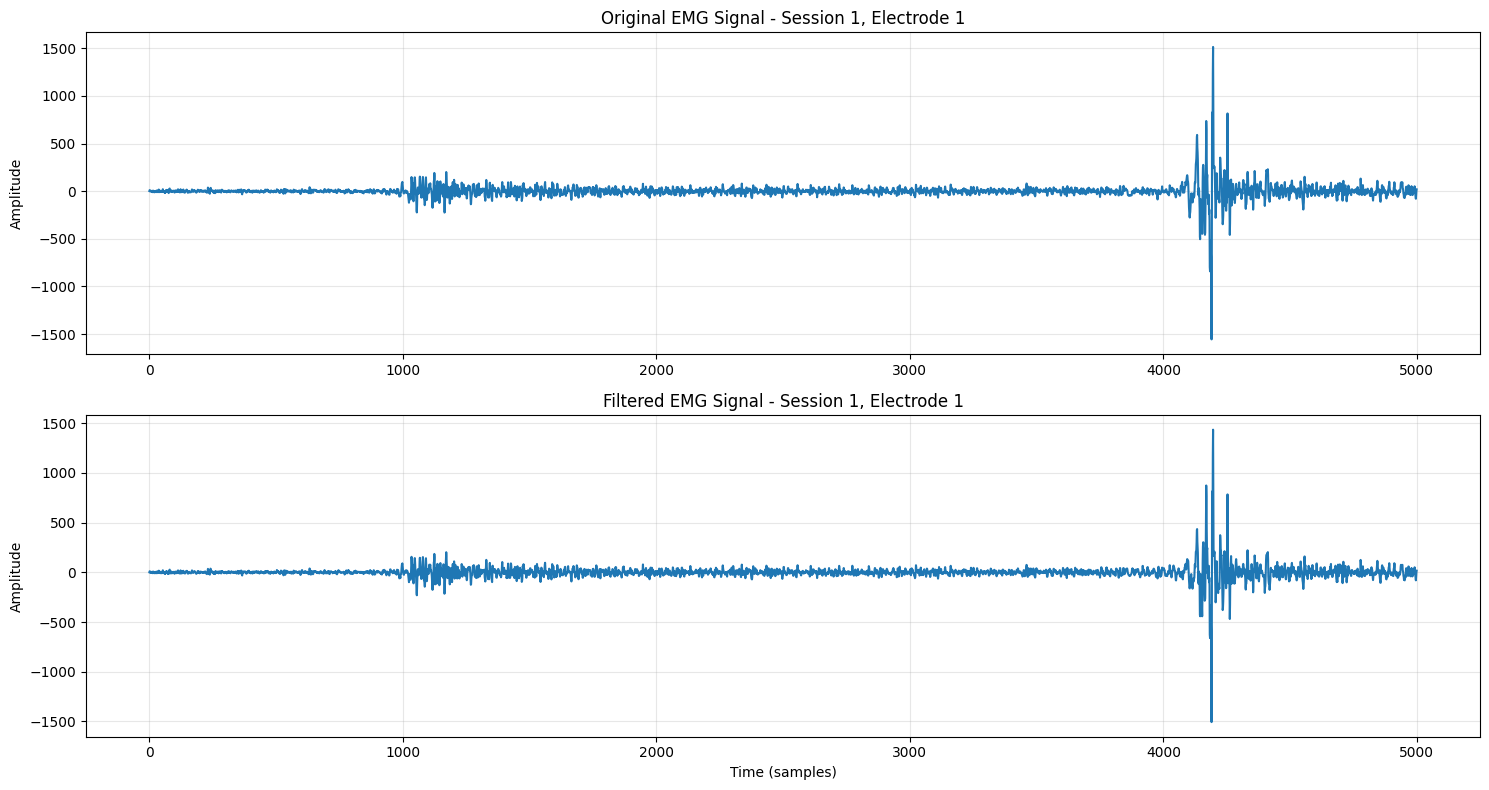


=== Step 3: Creating Windows with Overlap ===
Window size: 500, Overlap: 50%, Step size: 250
First few window indices to verify overlap:
Window 1: Session 1, Samples 1-500
Window 2: Session 1, Samples 251-750
Window 3: Session 1, Samples 501-1000
Window 4: Session 1, Samples 751-1250
Window 5: Session 1, Samples 1001-1500
Window creation completed in 1.76 seconds
Created 4595 windows with 50% overlap
X_windows shape: (4595, 8, 500)
y_windows shape: (4595, 51, 500)
Target values shape: (4595, 51)

=== Step 5: Extracting Features ===
Extracted features shape: (4595, 48)
Number of features: 48

=== Step 6: Creating Cross-Validation Splits ===
Split 1: 3676 training windows, 919 test windows
Split 2: 3676 training windows, 919 test windows
Split 3: 3676 training windows, 919 test windows
Split 4: 3676 training windows, 919 test windows
Split 5: 3676 training windows, 919 test windows

=== Step 7: Applying Feature Selection ===
Performing feature selection...
Target has multiple outputs. U

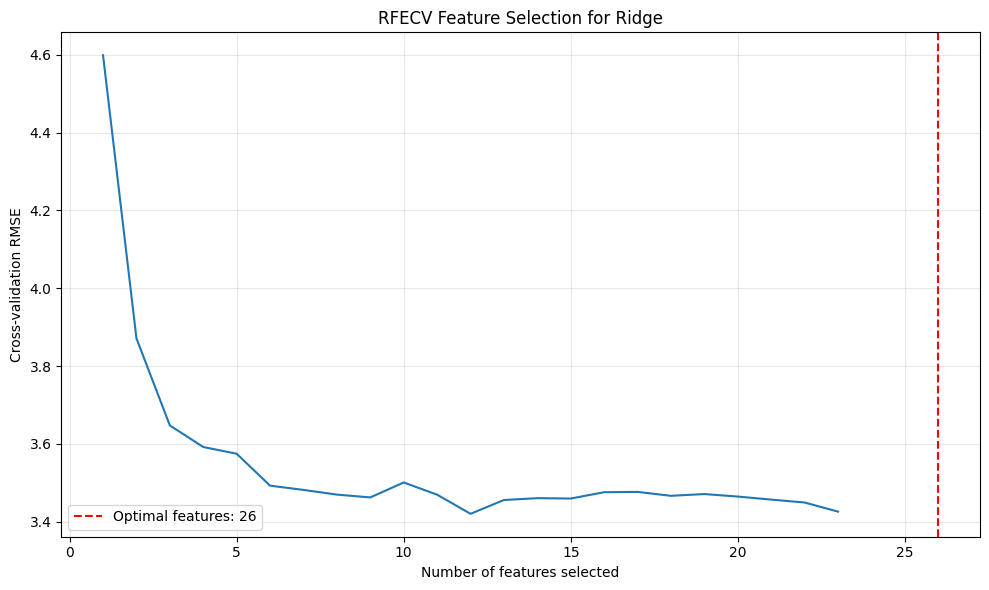


B. Performing Feature Importance Thresholding...

Feature importance analysis for Ridge...
  Using absolute coefficient values for feature ranking
  Top 10 features: ['E2_MAV', 'E7_VAR', 'E1_MAV', 'E7_MAV', 'E8_MAV', 'E2_VAR', 'E2_RMS', 'E2_STD', 'E7_RMS', 'E7_STD']
  Time taken: 0.01 seconds


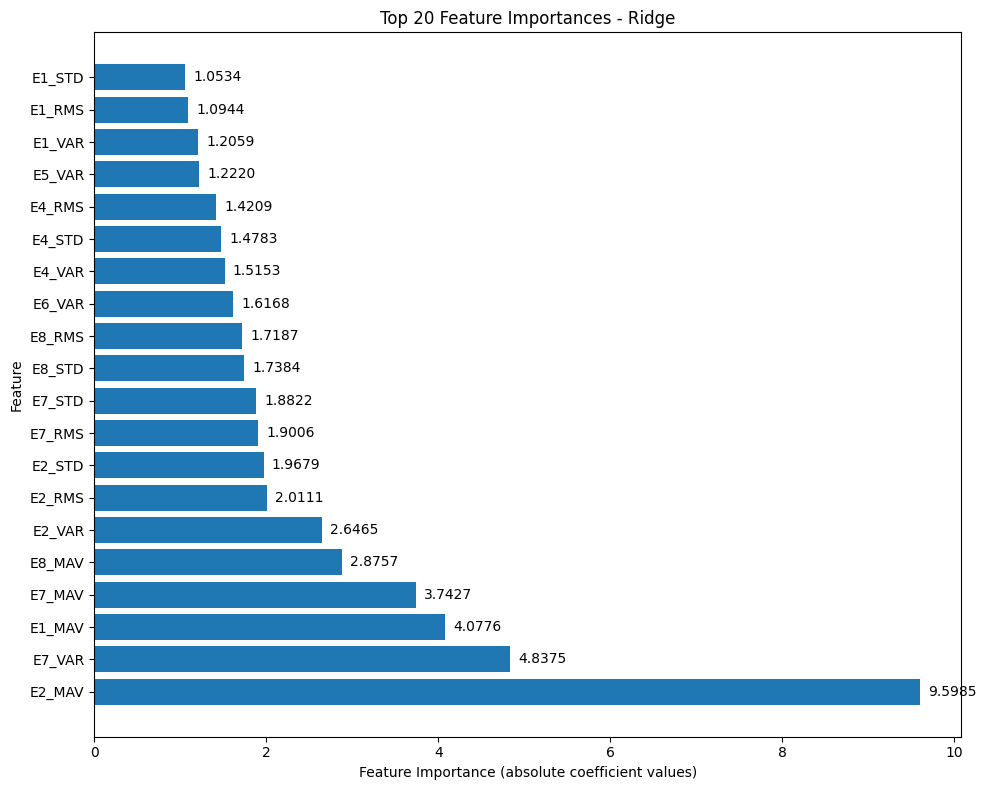


Finding optimal importance threshold for Ridge...
  Testing top 5 features...
    Average RMSE with top 5 features: 10.3282
  Testing top 10 features...
    Average RMSE with top 10 features: 9.6304
  Testing top 20 features...
    Average RMSE with top 20 features: 8.7394
  Testing top 40 features...
    Average RMSE with top 40 features: 7.8672
  Testing top 48 features...
    Average RMSE with top 48 features: 7.8637
  Optimal number of features for Ridge: 48
  Selected features: ['E2_MAV', 'E7_VAR', 'E1_MAV', 'E7_MAV', 'E8_MAV', 'E2_VAR', 'E2_RMS', 'E2_STD', 'E7_RMS', 'E7_STD']... (showing first 10)


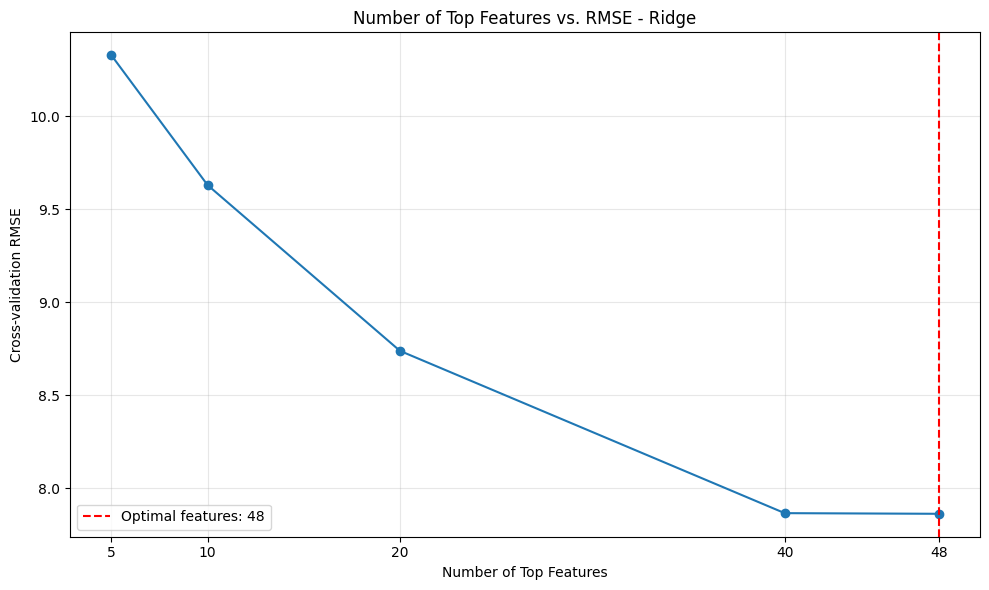


Feature Selection Summary:
  Ridge with RFECV: 26 features, RMSE = 8.0125
  Ridge with Importance: 48 features, RMSE = 7.8637

Best feature selection configuration:
  Model: Ridge
  Selection Method: Importance
  Number of Features: 48
  Cross-Validation RMSE: 7.8637


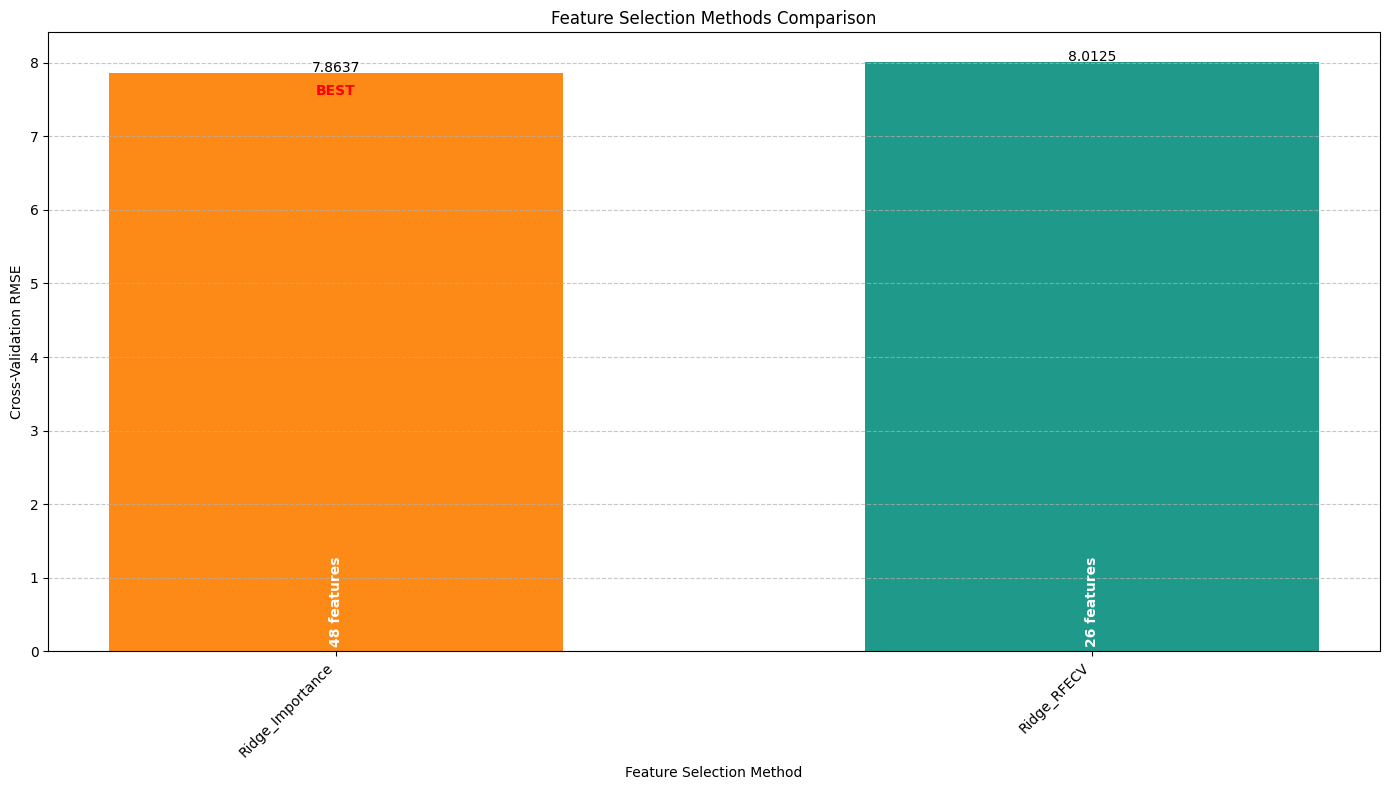

Selected features shape: (4595, 48)

=== Step 8: Comparing Regression Models ===

Evaluating Ridge Regression...
  Fold 1/5: Training on 3676 samples, testing on 919 samples
    RMSE = 8.6597, NMSE = 0.4121
  Fold 2/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.7602, NMSE = 0.3232
  Fold 3/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.8722, NMSE = 0.3110
  Fold 4/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.2627, NMSE = 0.2830
  Fold 5/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.7644, NMSE = 0.3047
  Average RMSE: 7.8638, Average NMSE: 0.3268
  Time taken: 0.13 seconds

Evaluating Lasso Regression...
  Fold 1/5: Training on 3676 samples, testing on 919 samples
    RMSE = 8.6423, NMSE = 0.4104
  Fold 2/5: Training on 3676 samples, testing on 919 samples


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(


    RMSE = 7.7626, NMSE = 0.3234
  Fold 3/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.8885, NMSE = 0.3123
  Fold 4/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.2658, NMSE = 0.2832
  Fold 5/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.7639, NMSE = 0.3047
  Average RMSE: 7.8646, Average NMSE: 0.3268
  Time taken: 24.00 seconds

Evaluating Random Forest...
  Fold 1/5: Training on 3676 samples, testing on 919 samples
    RMSE = 6.0498, NMSE = 0.2011
  Fold 2/5: Training on 3676 samples, testing on 919 samples
    RMSE = 5.1058, NMSE = 0.1399
  Fold 3/5: Training on 3676 samples, testing on 919 samples
    RMSE = 5.7486, NMSE = 0.1658
  Fold 4/5: Training on 3676 samples, testing on 919 samples
    RMSE = 5.0606, NMSE = 0.1374
  Fold 5/5: Training on 3676 samples, testing on 919 samples
    RMSE = 5.4590, NMSE = 0.1506
  Average RMSE: 5.4848, Average NMSE: 0.1590
  Time taken: 260.65 seconds

Best model by RMSE: Random Forest (RMS

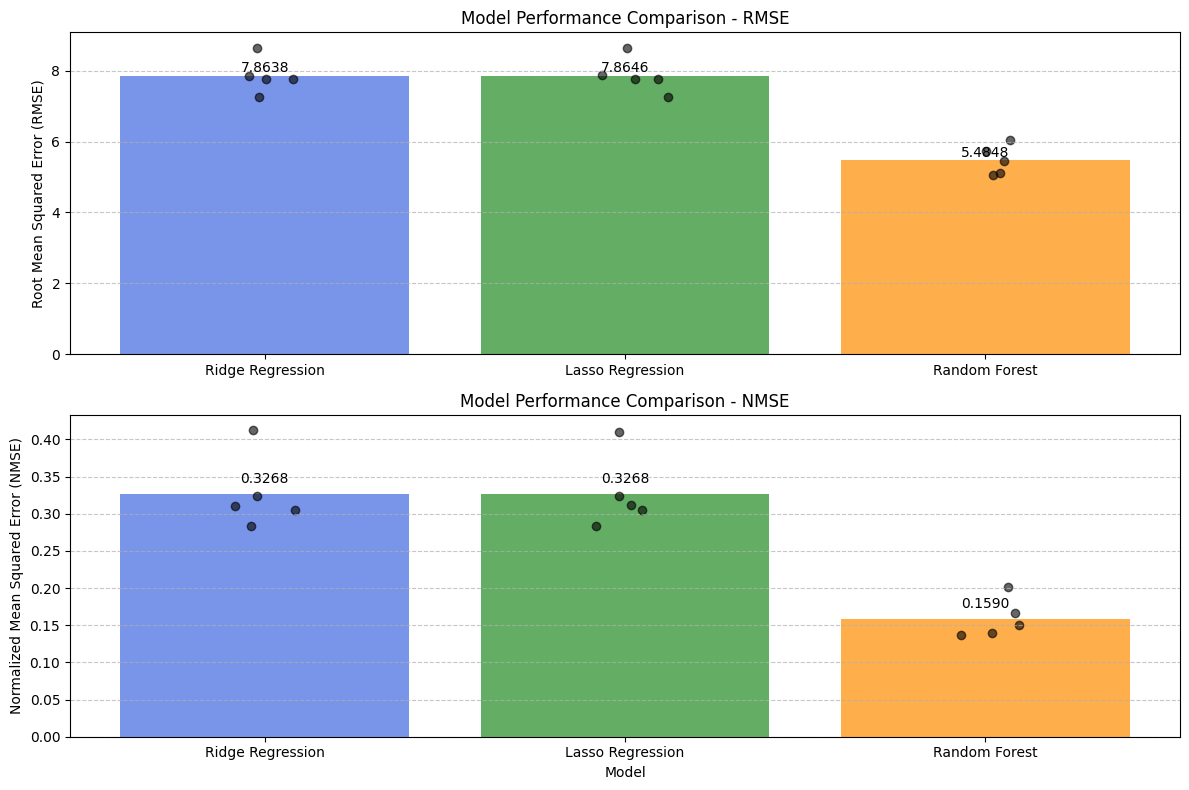


=== Step 9: Training Final Model ===
Final model trained: Random Forest
Training completed in 68.41 seconds

=== Step 10: Generating Predictions for Test Data Using Random Forest ===
Generating predictions for 1660 test windows...
Processing session 1/5...
  Processed 100/1660 windows (6.0%) - Elapsed: 1.2s
  Processed 200/1660 windows (12.0%) - Elapsed: 1.3s
  Processed 300/1660 windows (18.1%) - Elapsed: 1.5s
  Processed 332/1660 windows (20.0%) - Elapsed: 1.6s
Processing session 2/5...
  Processed 432/1660 windows (26.0%) - Elapsed: 2.8s
  Processed 532/1660 windows (32.0%) - Elapsed: 2.9s
  Processed 632/1660 windows (38.1%) - Elapsed: 3.1s
  Processed 664/1660 windows (40.0%) - Elapsed: 3.1s
Processing session 3/5...
  Processed 764/1660 windows (46.0%) - Elapsed: 4.4s
  Processed 864/1660 windows (52.0%) - Elapsed: 4.7s
  Processed 964/1660 windows (58.1%) - Elapsed: 4.8s
  Processed 996/1660 windows (60.0%) - Elapsed: 4.9s
Processing session 4/5...
  Processed 1096/1660 windows

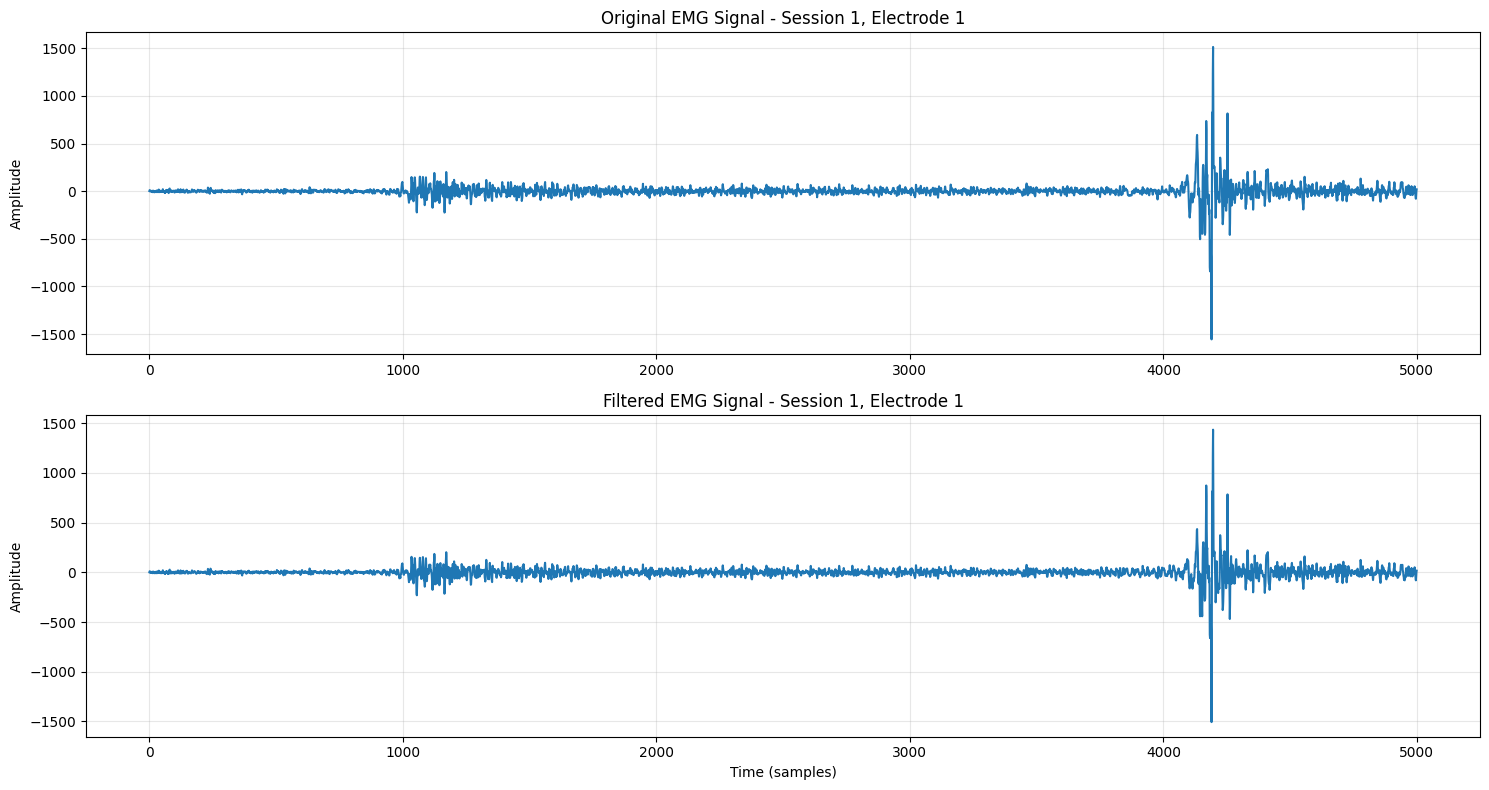


=== Step 3: Creating Windows with Overlap ===
Window size: 500, Overlap: 50%, Step size: 250
First few window indices to verify overlap:
Window 1: Session 1, Samples 1-500
Window 2: Session 1, Samples 251-750
Window 3: Session 1, Samples 501-1000
Window 4: Session 1, Samples 751-1250
Window 5: Session 1, Samples 1001-1500
Window creation completed in 0.58 seconds
Created 4595 windows with 50% overlap
X_windows shape: (4595, 8, 500)
y_windows shape: (4595, 51, 500)
Target values shape: (4595, 51)

=== Step 5: Extracting Features ===
Extracted features shape: (4595, 48)
Number of features: 48

=== Step 6: Creating Cross-Validation Splits ===
Split 1: 3676 training windows, 919 test windows
Split 2: 3676 training windows, 919 test windows
Split 3: 3676 training windows, 919 test windows
Split 4: 3676 training windows, 919 test windows
Split 5: 3676 training windows, 919 test windows

=== Step 7: Applying Feature Selection ===
Performing feature selection...
Target has multiple outputs. U

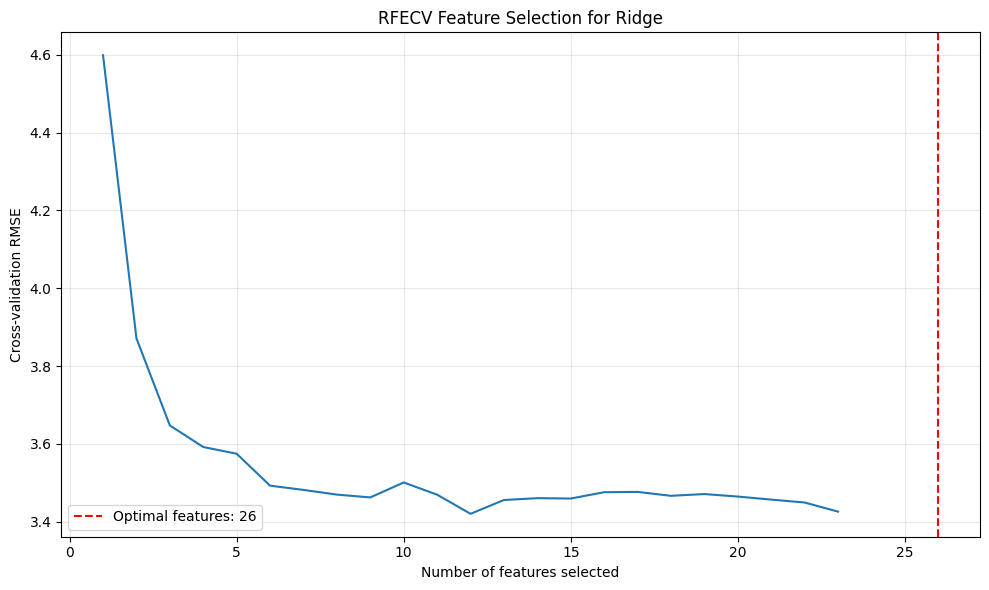


B. Performing Feature Importance Thresholding...

Feature importance analysis for Ridge...
  Using absolute coefficient values for feature ranking
  Top 10 features: ['E2_MAV', 'E7_VAR', 'E1_MAV', 'E7_MAV', 'E8_MAV', 'E2_VAR', 'E2_RMS', 'E2_STD', 'E7_RMS', 'E7_STD']
  Time taken: 0.06 seconds


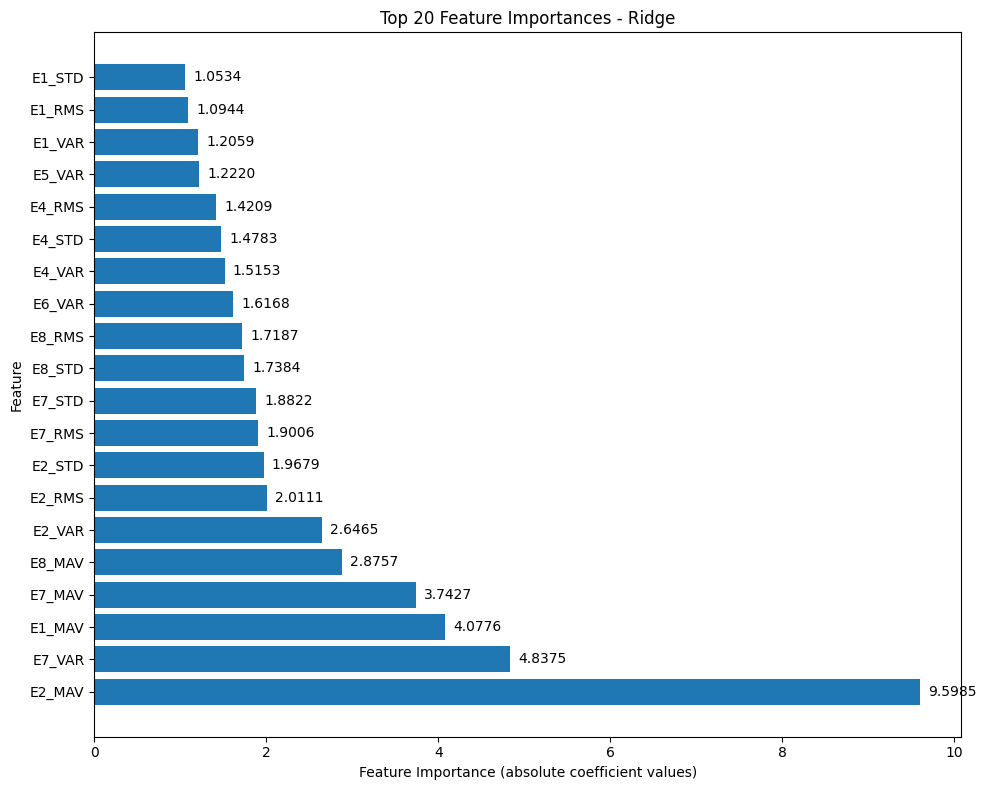


Finding optimal importance threshold for Ridge...
  Testing top 5 features...
    Average RMSE with top 5 features: 10.3282
  Testing top 10 features...
    Average RMSE with top 10 features: 9.6304
  Testing top 20 features...
    Average RMSE with top 20 features: 8.7394
  Testing top 40 features...
    Average RMSE with top 40 features: 7.8672
  Testing top 48 features...
    Average RMSE with top 48 features: 7.8637
  Optimal number of features for Ridge: 48
  Selected features: ['E2_MAV', 'E7_VAR', 'E1_MAV', 'E7_MAV', 'E8_MAV', 'E2_VAR', 'E2_RMS', 'E2_STD', 'E7_RMS', 'E7_STD']... (showing first 10)


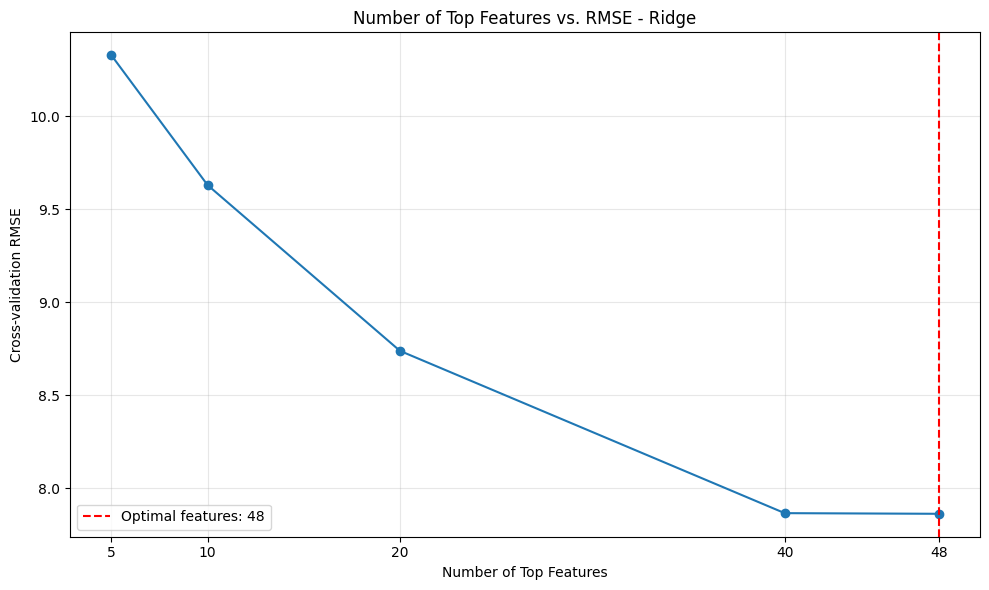


Feature Selection Summary:
  Ridge with RFECV: 26 features, RMSE = 8.0125
  Ridge with Importance: 48 features, RMSE = 7.8637

Best feature selection configuration:
  Model: Ridge
  Selection Method: Importance
  Number of Features: 48
  Cross-Validation RMSE: 7.8637


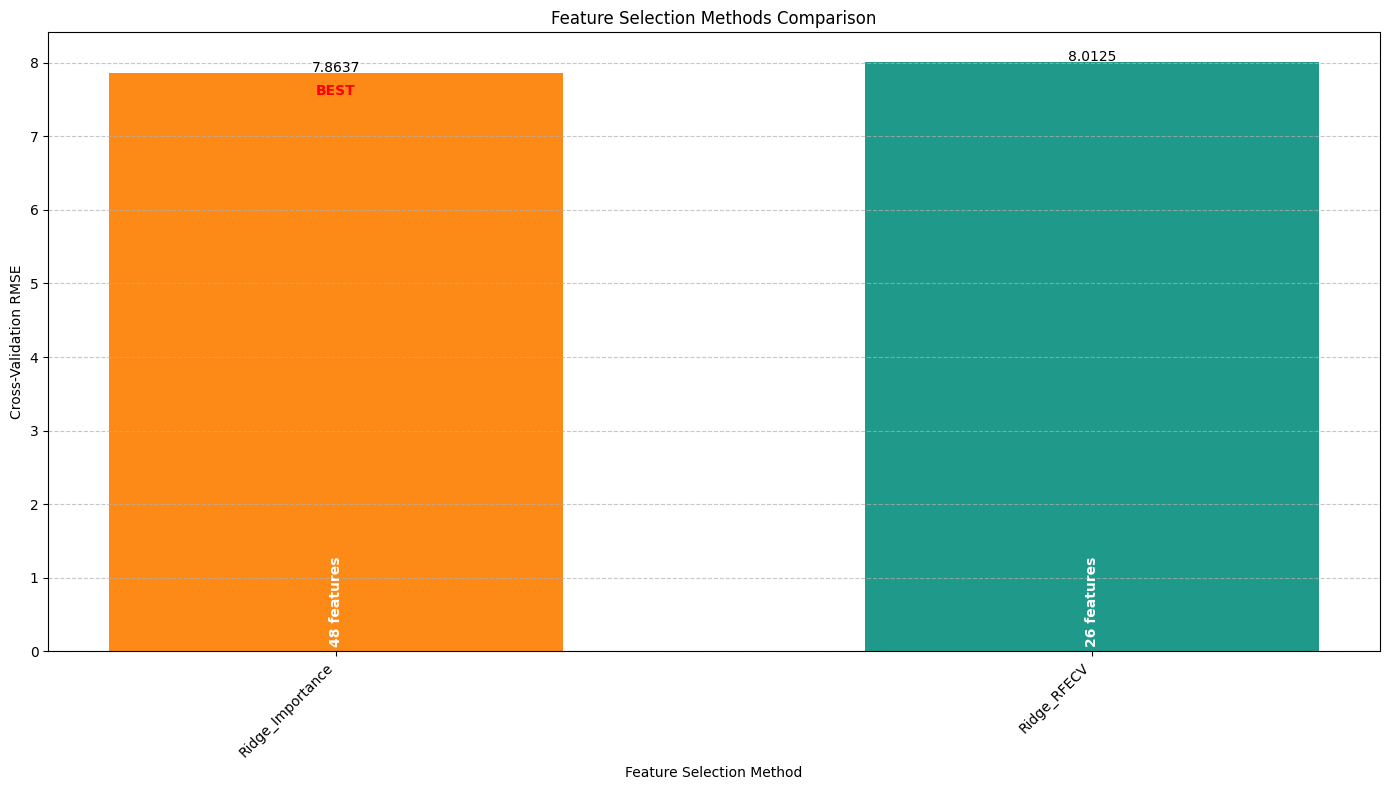

Selected features shape: (4595, 48)

=== Step 8: Comparing Regression Models ===

Evaluating Ridge Regression...
  Fold 1/5: Training on 3676 samples, testing on 919 samples
    RMSE = 8.6597, NMSE = 0.4121
  Fold 2/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.7602, NMSE = 0.3232
  Fold 3/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.8722, NMSE = 0.3110
  Fold 4/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.2627, NMSE = 0.2830
  Fold 5/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.7644, NMSE = 0.3047
  Average RMSE: 7.8638, Average NMSE: 0.3268
  Time taken: 0.38 seconds

Evaluating Lasso Regression...
  Fold 1/5: Training on 3676 samples, testing on 919 samples
    RMSE = 8.6423, NMSE = 0.4104
  Fold 2/5: Training on 3676 samples, testing on 919 samples


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(


    RMSE = 7.7626, NMSE = 0.3234
  Fold 3/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.8885, NMSE = 0.3123
  Fold 4/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.2658, NMSE = 0.2832
  Fold 5/5: Training on 3676 samples, testing on 919 samples
    RMSE = 7.7639, NMSE = 0.3047
  Average RMSE: 7.8646, Average NMSE: 0.3268
  Time taken: 27.80 seconds

Evaluating Random Forest...
  Fold 1/5: Training on 3676 samples, testing on 919 samples
    RMSE = 6.0498, NMSE = 0.2011
  Fold 2/5: Training on 3676 samples, testing on 919 samples
    RMSE = 5.1058, NMSE = 0.1399
  Fold 3/5: Training on 3676 samples, testing on 919 samples
    RMSE = 5.7486, NMSE = 0.1658
  Fold 4/5: Training on 3676 samples, testing on 919 samples
    RMSE = 5.0606, NMSE = 0.1374
  Fold 5/5: Training on 3676 samples, testing on 919 samples
    RMSE = 5.4590, NMSE = 0.1506
  Average RMSE: 5.4848, Average NMSE: 0.1590
  Time taken: 468.00 seconds

Best model by RMSE: Random Forest (RMS

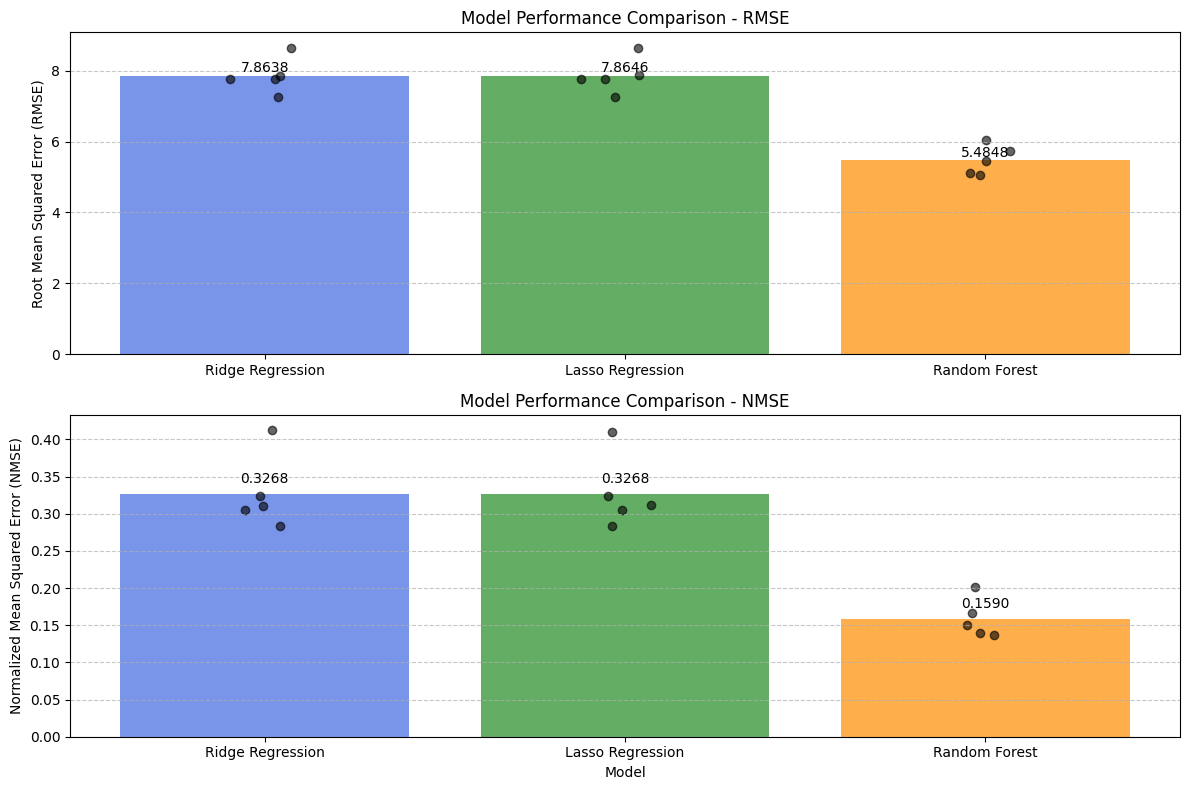


=== Step 9: Training Final Model ===
Final model trained: Random Forest
Training completed in 126.35 seconds

=== Step 10: Generating Predictions for Test Data Using Random Forest ===
Generating predictions for 1660 test windows...
Processing session 1/5...
  Processed 100/1660 windows (6.0%) - Elapsed: 11.6s
  Processed 200/1660 windows (12.0%) - Elapsed: 12.7s
  Processed 300/1660 windows (18.1%) - Elapsed: 14.0s
  Processed 332/1660 windows (20.0%) - Elapsed: 14.1s
Processing session 2/5...
  Processed 432/1660 windows (26.0%) - Elapsed: 15.6s
  Processed 532/1660 windows (32.0%) - Elapsed: 16.1s
  Processed 632/1660 windows (38.1%) - Elapsed: 16.4s
  Processed 664/1660 windows (40.0%) - Elapsed: 16.5s
Processing session 3/5...
  Processed 764/1660 windows (46.0%) - Elapsed: 18.1s
  Processed 864/1660 windows (52.0%) - Elapsed: 18.4s
  Processed 964/1660 windows (58.1%) - Elapsed: 18.6s
  Processed 996/1660 windows (60.0%) - Elapsed: 18.7s
Processing session 4/5...
  Processed 1096

In [28]:
def run_emg_analysis_pipeline(X_data_path, y_data_path, test_data_path=None, 
                           window_size=500, overlap_percent=50, apply_filtering=True,
                           feature_set='all', apply_feature_selection=True,
                           model_type=None):
    """
    Run the complete EMG analysis pipeline.
    
    Parameters:
    -----------
    X_data_path : str
        Path to the EMG data file
    y_data_path : str
        Path to the joint angle data file
    test_data_path : str, optional
        Path to the test data file
    window_size : int
        Size of each window in samples
    overlap_percent : float
        Percentage of overlap between consecutive windows
    apply_filtering : bool
        Whether to apply signal filtering
    feature_set : str
        Feature set to use ('all', 'basic')
    apply_feature_selection : bool
        Whether to apply feature selection
    model_type : str, optional
        Type of model to use for final prediction. If None, best model will be used.
        
    Returns:
    --------
    results : dict
        Results of the analysis pipeline
    """
    # 1. Load data
    print("\n=== Step 1: Loading Data ===")
    try:
        X_data = np.load(X_data_path)
        y_data = np.load(y_data_path)
        print(f"Loaded X data with shape: {X_data.shape}")
        print(f"Loaded y data with shape: {y_data.shape}")
        
        if test_data_path:
            test_data = np.load(test_data_path)
            print(f"Loaded test data with shape: {test_data.shape}")
        else:
            test_data = None
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    
    # 2. Apply signal filtering (if enabled)
    if apply_filtering:
        print("\n=== Step 2: Applying Signal Filtering ===")
        start_time = time.time()
        filtered_X = recommended_emg_filter(X_data)
        print(f"Filtering completed in {time.time() - start_time:.2f} seconds")
        
        # Visualize the filtered signal for one electrode
        visualize_filtered_signals(X_data, filtered_X)
        
        # Use the filtered data for further processing
        data_to_use = filtered_X
    else:
        print("\n=== Step 2: Skipping Signal Filtering ===")
        data_to_use = X_data
    
    # 3. Create windows with overlap
    print("\n=== Step 3: Creating Windows with Overlap ===")
    start_time = time.time()
    X_windows, y_windows, window_indices = create_matching_windows(
        data_to_use, y_data, window_size=window_size, overlap_percent=overlap_percent
    )
    print(f"Window creation completed in {time.time() - start_time:.2f} seconds")
    print(f"Created {len(window_indices)} windows with {overlap_percent}% overlap")
    print(f"X_windows shape: {X_windows.shape}")
    print(f"y_windows shape: {y_windows.shape}")
    
    # 4. Calculate mean joint angle in each window as the target
    y_targets = np.mean(y_windows, axis=2)
    print(f"Target values shape: {y_targets.shape}")
    
    # 5. Extract features
    print("\n=== Step 5: Extracting Features ===")
    feature_extractor = EMGFeatureExtractor(feature_set=feature_set)
    X_features = feature_extractor.transform(X_windows)
    feature_names = feature_extractor.get_feature_names()
    print(f"Extracted features shape: {X_features.shape}")
    print(f"Number of features: {len(feature_names)}")
    
    # 6. Create cross-validation splits
    print("\n=== Step 6: Creating Cross-Validation Splits ===")
    cv_splits = leave_one_session_out_cv(window_indices, n_sessions=X_data.shape[0])
    
    # 7. Apply feature selection (if enabled)
    if apply_feature_selection:
        print("\n=== Step 7: Applying Feature Selection ===")
        # Normalize features for feature selection
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_features)
        
        # Perform feature selection with all models
        best_features, feature_selection_results = perform_feature_selection(
            X_scaled, y_targets, cv_splits, feature_names
        )
        
        # Find best configuration
        summary_data = []
        for method_key, results in feature_selection_results.items():
            model_name = results['model_name']
            selection_method = results['method']
            n_features = results['optimal_n_features']
            
            # Get the cross-validation RMSE (already computed in perform_feature_selection)
            for summary_item in summary_data:
                if summary_item['method_key'] == method_key:
                    avg_rmse = summary_item['Cross-Val RMSE']
                    break
        
        # Find best method from summary data
        best_config = min([d for d in summary_data if 'Cross-Val RMSE' in d], 
                          key=lambda x: x['Cross-Val RMSE'], default=None)
        
        if best_config:
            best_method_key = best_config['method_key']
            best_features = feature_selection_results[best_method_key]['selected_indices']
            print(f"\nSelected best feature configuration: {best_method_key}")
            print(f"  Number of features: {len(best_features)}")
        
        # Select features
        X_selected = X_features[:, best_features]
        feature_names_selected = [feature_names[i] for i in best_features]
        print(f"Selected features shape: {X_selected.shape}")
        
        # Use selected features for model comparison
        X_for_models = X_selected
        feature_names_for_models = feature_names_selected
    else:
        print("\n=== Step 7: Skipping Feature Selection ===")
        X_for_models = X_features
        feature_names_for_models = feature_names
        feature_selection_results = None
    
    # 8. Compare regression models
    print("\n=== Step 8: Comparing Regression Models ===")
    
    # Define models to compare
    models = {
        'Ridge Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Ridge(alpha=1.0))
        ]),
        'Lasso Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Lasso(alpha=0.01, max_iter=10000))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
        ])
    }
    
    results = {}
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        start_time = time.time()
        
        # Cross-validation metrics
        fold_rmse = []
        fold_nmse = []
        
        # For each cross-validation fold
        for fold, (train_idx, test_idx) in enumerate(cv_splits):
            print(f"  Fold {fold+1}/{len(cv_splits)}: Training on {len(train_idx)} samples, testing on {len(test_idx)} samples")
            
            # Split the data
            X_train, X_test = X_for_models[train_idx], X_for_models[test_idx]
            y_train, y_test = y_targets[train_idx], y_targets[test_idx]
            
            # Train model
            model.fit(X_train, y_train)
            
            # Predict
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            # RMSE (Root Mean Squared Error)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            fold_rmse.append(rmse)
            
            # NMSE (Normalized Mean Squared Error)
            mse = np.mean((y_test - y_pred) ** 2)
            y_mean = np.mean(y_test, axis=0)
            var = np.mean((y_test - y_mean) ** 2)
            nmse = mse / var if var != 0 else float('inf')
            fold_nmse.append(nmse)
            
            print(f"    RMSE = {rmse:.4f}, NMSE = {nmse:.4f}")
        
        # Calculate average metrics
        avg_rmse = np.mean(fold_rmse)
        avg_nmse = np.mean(fold_nmse)
        
        # Store results
        results[name] = {
            'rmse': fold_rmse, 
            'avg_rmse': avg_rmse,
            'nmse': fold_nmse,
            'avg_nmse': avg_nmse,
            'model': model
        }
        
        print(f"  Average RMSE: {avg_rmse:.4f}, Average NMSE: {avg_nmse:.4f}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
    
    # Determine best model based on RMSE
    best_rmse_model_name = min(results, key=lambda x: results[x]['avg_rmse'])
    best_nmse_model_name = min(results, key=lambda x: results[x]['avg_nmse'])
    
    print(f"\nBest model by RMSE: {best_rmse_model_name} (RMSE = {results[best_rmse_model_name]['avg_rmse']:.4f})")
    print(f"Best model by NMSE: {best_nmse_model_name} (NMSE = {results[best_nmse_model_name]['avg_nmse']:.4f})")
    
    # If different models are best at RMSE and NMSE, prioritize RMSE
    if best_rmse_model_name != best_nmse_model_name:
        print(f"Models differ for RMSE and NMSE. Prioritizing RMSE model: {best_rmse_model_name}")
        
    best_model_name = best_rmse_model_name
    best_model = results[best_model_name]['model']
    
    # Create a bar chart to compare model performances
    visualize_model_comparison(results)
    
    # 9. Train final model on all data
    print("\n=== Step 9: Training Final Model ===")
    
    # Use specified model if provided, otherwise use best model
    if model_type and model_type in models:
        final_model_name = model_type
        final_model = models[model_type]
    else:
        final_model_name = best_model_name
        final_model = best_model
    
    # Train final model
    start_time = time.time()
    final_model.fit(X_for_models, y_targets)
    print(f"Final model trained: {final_model_name}")
    print(f"Training completed in {time.time() - start_time:.2f} seconds")
    
    # 10. Generate predictions for test data (if available)
    if test_data is not None:
        print(f"\n=== Step 10: Generating Predictions for Test Data Using {final_model_name} ===")
        
        # Create feature extractor with selected features
        if apply_feature_selection:
            prediction_feature_extractor = EMGFeatureExtractor(
                feature_set=feature_set, 
                selected_features_indices=best_features
            )
        else:
            prediction_feature_extractor = feature_extractor
        
        # Generate predictions
        predictions = predict_test_data(
            final_model, test_data, 
            prediction_feature_extractor, 
            preprocessor=None,  # No need for preprocessor as feature selection is handled in the extractor
            apply_filtering=apply_filtering
        )
        
        # Save predictions to CSV
        csv_filename = f"{final_model_name.lower().replace(' ', '_')}_predictions.csv"
        save_predictions_to_csv(predictions, csv_filename)
    else:
        predictions = None
    
    # 11. Return results
    results = {
        'X_windows': X_windows,
        'y_windows': y_windows,
        'window_indices': window_indices,
        'y_targets': y_targets,
        'X_features': X_features,
        'feature_names': feature_names,
        'cv_splits': cv_splits,
        'model_results': results,
        'best_model_name': best_model_name,
        'best_model': best_model,
        'final_model_name': final_model_name,
        'final_model': final_model,
        'predictions': predictions
    }
    
    if apply_feature_selection:
        results.update({
            'feature_selection_results': feature_selection_results,
            'best_features': best_features,
            'X_selected': X_for_models,
            'feature_names_selected': feature_names_for_models
        })
    
    print("\n=== Pipeline Completed Successfully ===")
    return results


def ensemble_prediction(models, test_data, feature_extractors, preprocessors=None,
                        ensemble_method='average', apply_filtering=True):
    """
    Generate ensemble predictions using multiple models.
    
    Parameters:
    -----------
    models : list
        List of trained models
    test_data : numpy.ndarray
        Test EMG data
    feature_extractors : list
        List of feature extractors (one for each model)
    preprocessors : list, optional
        List of preprocessors (one for each model)
    ensemble_method : str
        Method for ensembling ('average' or 'stacking')
    apply_filtering : bool
        Whether to apply signal filtering
        
    Returns:
    --------
    predictions : numpy.ndarray
        Ensemble predictions
    """
    print(f"\n=== Generating Ensemble Predictions ({ensemble_method}) ===")
    
    # Generate predictions from each base model
    all_model_predictions = []
    
    for i, model in enumerate(models):
        print(f"\nModel {i+1}/{len(models)}:")
        
        # Get feature extractor for this model
        feature_extractor = feature_extractors[i]
        
        # Get preprocessor for this model (if available)
        preprocessor = None if preprocessors is None else preprocessors[i]
        
        # Generate predictions
        model_preds = predict_test_data(
            model, test_data, feature_extractor, 
            preprocessor=preprocessor, apply_filtering=apply_filtering
        )
        
        all_model_predictions.append(model_preds)
    
    # Stack predictions for easier processing
    stacked_preds = np.stack(all_model_predictions, axis=0)
    print(f"Stacked predictions shape: {stacked_preds.shape}")
    
    # Apply ensemble method
    if ensemble_method == 'average':
        # Simple averaging of predictions
        ensemble_preds = np.mean(stacked_preds, axis=0)
        print("Ensemble method: Average of all model predictions")
    elif ensemble_method == 'stacking':
        # Stacking requires a meta-model
        # For simplicity, we'll use a weighted average here
        # In a real application, you would train a meta-model on validation data
        weights = np.ones(len(models)) / len(models)  # Equal weights
        ensemble_preds = np.tensordot(weights, stacked_preds, axes=([0], [0]))
        print("Ensemble method: Weighted average (equal weights)")
    else:
        raise ValueError(f"Unknown ensemble method: {ensemble_method}")
    
    print(f"Ensemble predictions shape: {ensemble_preds.shape}")
    
    return ensemble_preds


# Example usage
if __name__ == "__main__":
    # Set up data paths
    X_data_path = 'guided_dataset_X.npy'
    y_data_path = 'guided_dataset_y.npy'
    test_data_path = 'guided_testset_X.npy'
    
    # Load the data first - useful to avoid reloading for multiple pipeline runs
    try:
        guided_X = np.load(X_data_path)
        guided_y = np.load(y_data_path)
        guided_testset_X = np.load(test_data_path)
        print("Successfully loaded all datasets")
        print(f"Training data shapes: X={guided_X.shape}, y={guided_y.shape}")
        print(f"Test data shape: {guided_testset_X.shape}")
    except Exception as e:
        print(f"Error loading data: {e}")
    
    # Run the full pipeline with all models compared
    results = run_emg_analysis_pipeline(
        X_data_path, y_data_path, test_data_path,
        window_size=500, 
        overlap_percent=50,
        apply_filtering=True,
        feature_set='all',
        apply_feature_selection=True,
        # Let the pipeline choose the best model
        model_type=None
    )
    
    # Alternative: You can also specify a specific model if needed
    # results_rf = run_emg_analysis_pipeline(
    #     X_data_path, y_data_path, test_data_path,
    #     window_size=500,
    #     overlap_percent=50, 
    #     apply_filtering=True,
    #     feature_set='all',
    #     apply_feature_selection=True,
    #     model_type='Random Forest'
    # )

## 2nd try

In [ ]:
def run_emg_analysis_pipeline(X_data_path, y_data_path, test_data_path=None, 
                           window_size=500, overlap_percent=50, apply_filtering=True,
                           feature_set='all', apply_feature_selection=True,
                           model_type=None):
    """
    Run the complete EMG analysis pipeline.
    
    Parameters:
    -----------
    X_data_path : str
        Path to the EMG data file
    y_data_path : str
        Path to the joint angle data file
    test_data_path : str, optional
        Path to the test data file
    window_size : int
        Size of each window in samples
    overlap_percent : float
        Percentage of overlap between consecutive windows
    apply_filtering : bool
        Whether to apply signal filtering
    feature_set : str
        Feature set to use ('all', 'basic')
    apply_feature_selection : bool
        Whether to apply feature selection
    model_type : str, optional
        Type of model to use for final prediction. If None, best model will be used.
        
    Returns:
    --------
    results : dict
        Results of the analysis pipeline
    """
    # 1. Load data
    print("\n=== Step 1: Loading Data ===")
    try:
        X_data = np.load(X_data_path)
        y_data = np.load(y_data_path)
        print(f"Loaded X data with shape: {X_data.shape}")
        print(f"Loaded y data with shape: {y_data.shape}")
        
        if test_data_path:
            test_data = np.load(test_data_path)
            print(f"Loaded test data with shape: {test_data.shape}")
        else:
            test_data = None
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    
    # 2. Apply signal filtering (if enabled)
    if apply_filtering:
        print("\n=== Step 2: Applying Signal Filtering ===")
        start_time = time.time()
        filtered_X = recommended_emg_filter(X_data)
        print(f"Filtering completed in {time.time() - start_time:.2f} seconds")
        
        # Visualize the filtered signal for one electrode
        visualize_filtered_signals(X_data, filtered_X)
        
        # Use the filtered data for further processing
        data_to_use = filtered_X
    else:
        print("\n=== Step 2: Skipping Signal Filtering ===")
        data_to_use = X_data
    
    # 3. Create windows with overlap
    print("\n=== Step 3: Creating Windows with Overlap ===")
    start_time = time.time()
    X_windows, y_windows, window_indices = create_matching_windows(
        data_to_use, y_data, window_size=window_size, overlap_percent=overlap_percent
    )
    print(f"Window creation completed in {time.time() - start_time:.2f} seconds")
    print(f"Created {len(window_indices)} windows with {overlap_percent}% overlap")
    print(f"X_windows shape: {X_windows.shape}")
    print(f"y_windows shape: {y_windows.shape}")
    
    # 4. Calculate mean joint angle in each window as the target
    y_targets = np.mean(y_windows, axis=2)
    print(f"Target values shape: {y_targets.shape}")
    
    # 5. Extract features
    print("\n=== Step 5: Extracting Features ===")
    feature_extractor = EMGFeatureExtractor(feature_set=feature_set)
    X_features = feature_extractor.transform(X_windows)
    feature_names = feature_extractor.get_feature_names()
    print(f"Extracted features shape: {X_features.shape}")
    print(f"Number of features: {len(feature_names)}")
    
    # 6. Create cross-validation splits
    print("\n=== Step 6: Creating Cross-Validation Splits ===")
    cv_splits = leave_one_session_out_cv(window_indices, n_sessions=X_data.shape[0])
    
    # 7. Apply feature selection (if enabled)
    if apply_feature_selection:
        print("\n=== Step 7: Applying Feature Selection ===")
        # Normalize features for feature selection
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_features)
        
        # Define models for feature selection
        models_for_selection = {
            'Ridge': Ridge(alpha=1.0),
            'Lasso': Lasso(alpha=0.01, max_iter=10000),
            'RandomForest': RandomForestRegressor(n_estimators=50, random_state=42)
        }
        
        # Force use ALL models for feature selection
        print("Using ALL models (Ridge, Lasso, RandomForest) for feature selection")
        models_to_use = models_for_selection
        
        # Prepare target for feature selection
        if len(y_targets.shape) > 1 and y_targets.shape[1] > 1:
            print("Target has multiple outputs. Using mean target for feature selection.")
            y_for_selection = np.mean(y_targets, axis=1)
        else:
            y_for_selection = y_targets
        
        # A. Process each model separately for RFECV
        print("\nA. Performing Recursive Feature Elimination with Cross-Validation (RFECV)...")
        
        rfecv_results = {}
        feature_selection_results = {}
        
        # Ridge RFECV
        print("\nFeature selection for Ridge using RFECV...")
        ridge_model = models_for_selection['Ridge']
        start_time = time.time()
        
        ridge_rfecv = RFECV(
            estimator=ridge_model,
            step=max(1, len(feature_names) // 20),
            cv=3,
            scoring='neg_mean_squared_error',
            min_features_to_select=5,
            n_jobs=-1
        )
        
        ridge_rfecv.fit(X_scaled, y_for_selection)
        ridge_selected_indices = np.where(ridge_rfecv.support_)[0]
        ridge_selected_features = [feature_names[i] for i in ridge_selected_indices]
        
        print(f"  Optimal number of features: {ridge_rfecv.n_features_}")
        print(f"  Selected features: {ridge_selected_features[:10]}... (showing first 10)")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        feature_selection_results["Ridge_RFECV"] = {
            'method': 'RFECV',
            'model_name': 'Ridge',
            'model': ridge_model,
            'optimal_n_features': ridge_rfecv.n_features_,
            'selected_indices': ridge_selected_indices,
            'selected_features': ridge_selected_features,
            'grid_scores': ridge_rfecv.cv_results_['mean_test_score'],
        }
        
        # Plot Ridge RFECV
        plt.figure(figsize=(10, 6))
        plt.xlabel("Number of features selected")
        plt.ylabel("Cross-validation RMSE")
        ridge_rmse_scores = np.sqrt(-ridge_rfecv.cv_results_['mean_test_score'])
        plt.plot(range(1, len(ridge_rmse_scores) + 1), ridge_rmse_scores)
        plt.title(f"RFECV Feature Selection for Ridge")
        plt.axvline(x=ridge_rfecv.n_features_, color='r', linestyle='--', 
                    label=f'Optimal features: {ridge_rfecv.n_features_}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('rfecv_feature_selection_ridge.png', dpi=300)
        plt.show()
        
        # Lasso RFECV
        print("\nFeature selection for Lasso using RFECV...")
        lasso_model = models_for_selection['Lasso']
        start_time = time.time()
        
        lasso_rfecv = RFECV(
            estimator=lasso_model,
            step=max(1, len(feature_names) // 20),
            cv=3,
            scoring='neg_mean_squared_error',
            min_features_to_select=5,
            n_jobs=-1
        )
        
        lasso_rfecv.fit(X_scaled, y_for_selection)
        lasso_selected_indices = np.where(lasso_rfecv.support_)[0]
        lasso_selected_features = [feature_names[i] for i in lasso_selected_indices]
        
        print(f"  Optimal number of features: {lasso_rfecv.n_features_}")
        print(f"  Selected features: {lasso_selected_features[:10]}... (showing first 10)")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        feature_selection_results["Lasso_RFECV"] = {
            'method': 'RFECV',
            'model_name': 'Lasso',
            'model': lasso_model,
            'optimal_n_features': lasso_rfecv.n_features_,
            'selected_indices': lasso_selected_indices,
            'selected_features': lasso_selected_features,
            'grid_scores': lasso_rfecv.cv_results_['mean_test_score'],
        }
        
        # Plot Lasso RFECV
        plt.figure(figsize=(10, 6))
        plt.xlabel("Number of features selected")
        plt.ylabel("Cross-validation RMSE")
        lasso_rmse_scores = np.sqrt(-lasso_rfecv.cv_results_['mean_test_score'])
        plt.plot(range(1, len(lasso_rmse_scores) + 1), lasso_rmse_scores)
        plt.title(f"RFECV Feature Selection for Lasso")
        plt.axvline(x=lasso_rfecv.n_features_, color='r', linestyle='--', 
                    label=f'Optimal features: {lasso_rfecv.n_features_}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('rfecv_feature_selection_lasso.png', dpi=300)
        plt.show()
        
        # Random Forest RFECV
        print("\nFeature selection for RandomForest using RFECV...")
        rf_model = models_for_selection['RandomForest']
        start_time = time.time()
        
        rf_rfecv = RFECV(
            estimator=rf_model,
            step=max(1, len(feature_names) // 20),
            cv=3,
            scoring='neg_mean_squared_error',
            min_features_to_select=5,
            n_jobs=-1
        )
        
        rf_rfecv.fit(X_scaled, y_for_selection)
        rf_selected_indices = np.where(rf_rfecv.support_)[0]
        rf_selected_features = [feature_names[i] for i in rf_selected_indices]
        
        print(f"  Optimal number of features: {rf_rfecv.n_features_}")
        print(f"  Selected features: {rf_selected_features[:10]}... (showing first 10)")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        feature_selection_results["RandomForest_RFECV"] = {
            'method': 'RFECV',
            'model_name': 'RandomForest',
            'model': rf_model,
            'optimal_n_features': rf_rfecv.n_features_,
            'selected_indices': rf_selected_indices,
            'selected_features': rf_selected_features,
            'grid_scores': rf_rfecv.cv_results_['mean_test_score'],
        }
        
        # Plot RandomForest RFECV
        plt.figure(figsize=(10, 6))
        plt.xlabel("Number of features selected")
        plt.ylabel("Cross-validation RMSE")
        rf_rmse_scores = np.sqrt(-rf_rfecv.cv_results_['mean_test_score'])
        plt.plot(range(1, len(rf_rmse_scores) + 1), rf_rmse_scores)
        plt.title(f"RFECV Feature Selection for RandomForest")
        plt.axvline(x=rf_rfecv.n_features_, color='r', linestyle='--', 
                    label=f'Optimal features: {rf_rfecv.n_features_}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('rfecv_feature_selection_randomforest.png', dpi=300)
        plt.show()
        
        # Plot comparison of RFECV across models
        plt.figure(figsize=(12, 8))
        
        # Ridge
        plt.plot(range(1, len(ridge_rmse_scores) + 1), ridge_rmse_scores, 
                 color='blue', marker='o', markersize=6, 
                 label=f"Ridge (optimal: {ridge_rfecv.n_features_})")
        plt.axvline(x=ridge_rfecv.n_features_, color='blue', linestyle='--', alpha=0.7)
        
        # Lasso
        plt.plot(range(1, len(lasso_rmse_scores) + 1), lasso_rmse_scores, 
                 color='green', marker='s', markersize=6, 
                 label=f"Lasso (optimal: {lasso_rfecv.n_features_})")
        plt.axvline(x=lasso_rfecv.n_features_, color='green', linestyle='--', alpha=0.7)
        
        # Random Forest
        plt.plot(range(1, len(rf_rmse_scores) + 1), rf_rmse_scores, 
                 color='orange', marker='^', markersize=6, 
                 label=f"RandomForest (optimal: {rf_rfecv.n_features_})")
        plt.axvline(x=rf_rfecv.n_features_, color='orange', linestyle='--', alpha=0.7)
        
        plt.xlabel("Number of features selected")
        plt.ylabel("Cross-validation RMSE")
        plt.title("RFECV Feature Selection Comparison Across Models")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('rfecv_comparison.png', dpi=300)
        plt.show()
        
        # B. Feature Importance Thresholding for each model
        print("\nB. Performing Feature Importance Thresholding...")
        
        # Ridge importance
        print("\nFeature importance analysis for Ridge...")
        ridge_model = models_for_selection['Ridge']
        start_time = time.time()
        
        ridge_model.fit(X_scaled, y_for_selection)
        ridge_importances = np.abs(ridge_model.coef_).mean(axis=0) if len(ridge_model.coef_.shape) > 1 else np.abs(ridge_model.coef_)
        
        # Create importance scores dictionary for Ridge
        ridge_importance_dict = dict(zip(feature_names, ridge_importances))
        ridge_importance_dict = {k: v for k, v in sorted(
            ridge_importance_dict.items(), key=lambda item: item[1], reverse=True)}
        
        print(f"  Top 10 features: {list(ridge_importance_dict.keys())[:10]}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        # Store Ridge importance
        feature_selection_results[f"Ridge_Importance"] = {
            'method': 'Importance',
            'model_name': 'Ridge',
            'model': ridge_model,
            'importance_dict': ridge_importance_dict,
            'importance_values': ridge_importances,
            'importance_sorted_indices': np.argsort(ridge_importances)[::-1]
        }
        
        # Plot Ridge importance
        N = min(20, len(ridge_importance_dict))
        ridge_top_features = list(ridge_importance_dict.keys())[:N]
        ridge_top_importances = list(ridge_importance_dict.values())[:N]
        
        plt.figure(figsize=(10, 8))
        bars = plt.barh(range(N), ridge_top_importances, align='center')
        plt.yticks(range(N), ridge_top_features)
        plt.xlabel('Feature Importance (absolute coefficient values)')
        plt.ylabel('Feature')
        plt.title(f'Top {N} Feature Importances - Ridge')
        
        # Add value labels
        for i, v in enumerate(ridge_top_importances):
            plt.text(v + 0.01*max(ridge_top_importances), i, f"{v:.4f}", va='center')
            
        plt.tight_layout()
        plt.savefig('feature_importance_ridge.png', dpi=300)
        plt.show()
        
        # Lasso importance
        print("\nFeature importance analysis for Lasso...")
        lasso_model = models_for_selection['Lasso']
        start_time = time.time()
        
        lasso_model.fit(X_scaled, y_for_selection)
        lasso_importances = np.abs(lasso_model.coef_).mean(axis=0) if len(lasso_model.coef_.shape) > 1 else np.abs(lasso_model.coef_)
        
        # Create importance scores dictionary for Lasso
        lasso_importance_dict = dict(zip(feature_names, lasso_importances))
        lasso_importance_dict = {k: v for k, v in sorted(
            lasso_importance_dict.items(), key=lambda item: item[1], reverse=True)}
        
        print(f"  Top 10 features: {list(lasso_importance_dict.keys())[:10]}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        # Store Lasso importance
        feature_selection_results[f"Lasso_Importance"] = {
            'method': 'Importance',
            'model_name': 'Lasso',
            'model': lasso_model,
            'importance_dict': lasso_importance_dict,
            'importance_values': lasso_importances,
            'importance_sorted_indices': np.argsort(lasso_importances)[::-1]
        }
        
        # Plot Lasso importance
        N = min(20, len(lasso_importance_dict))
        lasso_top_features = list(lasso_importance_dict.keys())[:N]
        lasso_top_importances = list(lasso_importance_dict.values())[:N]
        
        plt.figure(figsize=(10, 8))
        bars = plt.barh(range(N), lasso_top_importances, align='center')
        plt.yticks(range(N), lasso_top_features)
        plt.xlabel('Feature Importance (absolute coefficient values)')
        plt.ylabel('Feature')
        plt.title(f'Top {N} Feature Importances - Lasso')
        
        # Add value labels
        for i, v in enumerate(lasso_top_importances):
            plt.text(v + 0.01*max(lasso_top_importances), i, f"{v:.4f}", va='center')
            
        plt.tight_layout()
        plt.savefig('feature_importance_lasso.png', dpi=300)
        plt.show()
        
        # RandomForest importance
        print("\nFeature importance analysis for RandomForest...")
        rf_model = models_for_selection['RandomForest']
        start_time = time.time()
        
        rf_model.fit(X_scaled, y_for_selection)
        rf_importances = rf_model.feature_importances_
        
        # Create importance scores dictionary for RandomForest
        rf_importance_dict = dict(zip(feature_names, rf_importances))
        rf_importance_dict = {k: v for k, v in sorted(
            rf_importance_dict.items(), key=lambda item: item[1], reverse=True)}
        
        print(f"  Top 10 features: {list(rf_importance_dict.keys())[:10]}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        # Store RandomForest importance
        feature_selection_results[f"RandomForest_Importance"] = {
            'method': 'Importance',
            'model_name': 'RandomForest',
            'model': rf_model,
            'importance_dict': rf_importance_dict,
            'importance_values': rf_importances,
            'importance_sorted_indices': np.argsort(rf_importances)[::-1]
        }
        
        # Plot RandomForest importance
        N = min(20, len(rf_importance_dict))
        rf_top_features = list(rf_importance_dict.keys())[:N]
        rf_top_importances = list(rf_importance_dict.values())[:N]
        
        plt.figure(figsize=(10, 8))
        bars = plt.barh(range(N), rf_top_importances, align='center')
        plt.yticks(range(N), rf_top_features)
        plt.xlabel('Feature Importance (feature importances)')
        plt.ylabel('Feature')
        plt.title(f'Top {N} Feature Importances - RandomForest')
        
        # Add value labels
        for i, v in enumerate(rf_top_importances):
            plt.text(v + 0.01*max(rf_top_importances), i, f"{v:.4f}", va='center')
            
        plt.tight_layout()
        plt.savefig('feature_importance_randomforest.png', dpi=300)
        plt.show()
        
        # C. Find optimal threshold for each model
        # Ridge threshold selection
        print("\nFinding optimal importance threshold for Ridge...")
        n_features_options = [5, 10, 20, 40]
        if len(feature_names) < 40:
            n_features_options = [n for n in n_features_options if n <= len(feature_names)]
        else:
            n_features_options.append(len(feature_names))
            n_features_options.sort()
        
        # Ridge threshold selection
        ridge_cv_rmse_scores = []
        
        for n_top_features in n_features_options:
            print(f"  Testing top {n_top_features} features...")
            top_indices = feature_selection_results[f"Ridge_Importance"]['importance_sorted_indices'][:n_top_features]
            
            fold_rmses = []
            for fold, (train_idx, test_idx) in enumerate(cv_splits):
                # Select data with top features
                X_train = X_features[train_idx][:, top_indices]
                X_test = X_features[test_idx][:, top_indices]
                y_train = y_targets[train_idx]
                y_test = y_targets[test_idx]
                
                model_cv = Ridge(alpha=1.0)
                model_cv.fit(X_train, y_train)
                y_pred = model_cv.predict(X_test)
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                fold_rmses.append(rmse)
            
            avg_rmse = np.mean(fold_rmses)
            ridge_cv_rmse_scores.append(avg_rmse)
            print(f"    Average RMSE with top {n_top_features} features: {avg_rmse:.4f}")
        
        ridge_optimal_idx = np.argmin(ridge_cv_rmse_scores)
        ridge_optimal_n_features = n_features_options[ridge_optimal_idx]
        
        ridge_top_indices = feature_selection_results[f"Ridge_Importance"]['importance_sorted_indices'][:ridge_optimal_n_features]
        ridge_top_features = [feature_names[i] for i in ridge_top_indices]
        
        feature_selection_results[f"Ridge_Importance"]['optimal_n_features'] = ridge_optimal_n_features
        feature_selection_results[f"Ridge_Importance"]['selected_indices'] = ridge_top_indices
        feature_selection_results[f"Ridge_Importance"]['selected_features'] = ridge_top_features
        
        print(f"  Optimal number of features for Ridge: {ridge_optimal_n_features}")
        print(f"  Selected features: {ridge_top_features[:10]}... (showing first 10)")
        
        # Plot Ridge threshold
        plt.figure(figsize=(10, 6))
        plt.plot(n_features_options, ridge_cv_rmse_scores, '-o')
        plt.xlabel('Number of Top Features')
        plt.ylabel('Cross-validation RMSE')
        plt.title('Number of Top Features vs. RMSE - Ridge')
        plt.axvline(x=ridge_optimal_n_features, color='r', linestyle='--', 
                    label=f'Optimal features: {ridge_optimal_n_features}')
        plt.xticks(n_features_options)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig('threshold_selection_ridge.png', dpi=300)
        plt.show()
        
        # Lasso threshold selection
        print("\nFinding optimal importance threshold for Lasso...")
        lasso_cv_rmse_scores = []
        
        for n_top_features in n_features_options:
            print(f"  Testing top {n_top_features} features...")
            top_indices = feature_selection_results[f"Lasso_Importance"]['importance_sorted_indices'][:n_top_features]
            
            fold_rmses = []
            for fold, (train_idx, test_idx) in enumerate(cv_splits):
                # Select data with top features
                X_train = X_features[train_idx][:, top_indices]
                X_test = X_features[test_idx][:, top_indices]
                y_train = y_targets[train_idx]
                y_test = y_targets[test_idx]
                
                model_cv = Lasso(alpha=0.01, max_iter=10000)
                model_cv.fit(X_train, y_train)
                y_pred = model_cv.predict(X_test)
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                fold_rmses.append(rmse)
            
            avg_rmse = np.mean(fold_rmses)
            lasso_cv_rmse_scores.append(avg_rmse)
            print(f"    Average RMSE with top {n_top_features} features: {avg_rmse:.4f}")
        
        lasso_optimal_idx = np.argmin(lasso_cv_rmse_scores)
        lasso_optimal_n_features = n_features_options[lasso_optimal_idx]
        
        lasso_top_indices = feature_selection_results[f"Lasso_Importance"]['importance_sorted_indices'][:lasso_optimal_n_features]
        lasso_top_features = [feature_names[i] for i in lasso_top_indices]
        
        feature_selection_results[f"Lasso_Importance"]['optimal_n_features'] = lasso_optimal_n_features
        feature_selection_results[f"Lasso_Importance"]['selected_indices'] = lasso_top_indices
        feature_selection_results[f"Lasso_Importance"]['selected_features'] = lasso_top_features
        
        print(f"  Optimal number of features for Lasso: {lasso_optimal_n_features}")
        print(f"  Selected features: {lasso_top_features[:10]}... (showing first 10)")
        
        # Plot Lasso threshold
        plt.figure(figsize=(10, 6))
        plt.plot(n_features_options, lasso_cv_rmse_scores, '-o')
        plt.xlabel('Number of Top Features')
        plt.ylabel('Cross-validation RMSE')
        plt.title('Number of Top Features vs. RMSE - Lasso')
        plt.axvline(x=lasso_optimal_n_features, color='r', linestyle='--', 
                    label=f'Optimal features: {lasso_optimal_n_features}')
        plt.xticks(n_features_options)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig('threshold_selection_lasso.png', dpi=300)
        plt.show()
        
        # RandomForest threshold selection
        print("\nFinding optimal importance threshold for RandomForest...")
        rf_cv_rmse_scores = []
        
        for n_top_features in n_features_options:
            print(f"  Testing top {n_top_features} features...")
            top_indices = feature_selection_results[f"RandomForest_Importance"]['importance_sorted_indices'][:n_top_features]
            
            fold_rmses = []
            for fold, (train_idx, test_idx) in enumerate(cv_splits):
                # Select data with top features
                X_train = X_features[train_idx][:, top_indices]
                X_test = X_features[test_idx][:, top_indices]
                y_train = y_targets[train_idx]
                y_test = y_targets[test_idx]
                
                model_cv = RandomForestRegressor(n_estimators=50, random_state=42)
                model_cv.fit(X_train, y_train)
                y_pred = model_cv.predict(X_test)
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                fold_rmses.append(rmse)
            
            avg_rmse = np.mean(fold_rmses)
            rf_cv_rmse_scores.append(avg_rmse)
            print(f"    Average RMSE with top {n_top_features} features: {avg_rmse:.4f}")
        
        rf_optimal_idx = np.argmin(rf_cv_rmse_scores)
        rf_optimal_n_features = n_features_options[rf_optimal_idx]
        
        rf_top_indices = feature_selection_results[f"RandomForest_Importance"]['importance_sorted_indices'][:rf_optimal_n_features]
        rf_top_features = [feature_names[i] for i in rf_top_indices]
        
        feature_selection_results[f"RandomForest_Importance"]['optimal_n_features'] = rf_optimal_n_features
        feature_selection_results[f"RandomForest_Importance"]['selected_indices'] = rf_top_indices
        feature_selection_results[f"RandomForest_Importance"]['selected_features'] = rf_top_features
        
        print(f"  Optimal number of features for RandomForest: {rf_optimal_n_features}")
        print(f"  Selected features: {rf_top_features[:10]}... (showing first 10)")
        
        # Plot RandomForest threshold
        plt.figure(figsize=(10, 6))
        plt.plot(n_features_options, rf_cv_rmse_scores, '-o')
        plt.xlabel('Number of Top Features')
        plt.ylabel('Cross-validation RMSE')
        plt.title('Number of Top Features vs. RMSE - RandomForest')
        plt.axvline(x=rf_optimal_n_features, color='r', linestyle='--', 
                    label=f'Optimal features: {rf_optimal_n_features}')
        plt.xticks(n_features_options)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig('threshold_selection_randomforest.png', dpi=300)
        plt.show()
        
        # Plot threshold comparison
        plt.figure(figsize=(12, 8))
        plt.plot(n_features_options, ridge_cv_rmse_scores, '-o', color='blue', label=f"Ridge (optimal: {ridge_optimal_n_features})")
        plt.plot(n_features_options, lasso_cv_rmse_scores, '-s', color='green', label=f"Lasso (optimal: {lasso_optimal_n_features})")
        plt.plot(n_features_options, rf_cv_rmse_scores, '-^', color='orange', label=f"RandomForest (optimal: {rf_optimal_n_features})")
        
        plt.axvline(x=ridge_optimal_n_features, color='blue', linestyle='--', alpha=0.7)
        plt.axvline(x=lasso_optimal_n_features, color='green', linestyle='--', alpha=0.7)
        plt.axvline(x=rf_optimal_n_features, color='orange', linestyle='--', alpha=0.7)
        
        plt.xlabel('Number of Top Features')
        plt.ylabel('Cross-validation RMSE')
        plt.title('Feature Importance Thresholding Comparison Across Models')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('feature_importance_comparison.png', dpi=300)
        plt.show()
        
        # D. Feature selection method comparison
        print("\nFeature Selection Summary:")
        summary_data = []
        
        for method_key, results in feature_selection_results.items():
            model_name = results['model_name']
            selection_method = results['method']
            n_features = results['optimal_n_features']
            
            # Evaluate model with selected features 
            cv_rmses = []
            
            for fold, (train_idx, test_idx) in enumerate(cv_splits):
                # Get selected feature indices
                selected_indices = results['selected_indices']
                
                # Select features
                X_train = X_features[train_idx][:, selected_indices]
                X_test = X_features[test_idx][:, selected_indices]
                y_train = y_targets[train_idx]
                y_test = y_targets[test_idx]
                
                # Create a fresh model instance
                if model_name == 'Ridge':
                    model_cv = Ridge(alpha=1.0)
                elif model_name == 'Lasso':
                    model_cv = Lasso(alpha=0.01, max_iter=10000)
                else:
                    model_cv = RandomForestRegressor(n_estimators=50, random_state=42)
                
                # Train model
                model_cv.fit(X_train, y_train)
                
                # Predict
                y_pred = model_cv.predict(X_test)
                
                # Calculate RMSE
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                cv_rmses.append(rmse)
            
            # Calculate average RMSE
            avg_rmse = np.mean(cv_rmses)
            
            # Add to summary
            summary_data.append({
                'Model': model_name,
                'Selection Method': selection_method,
                'Optimal Features': n_features,
                'Cross-Val RMSE': avg_rmse,
                'method_key': method_key  # Store the original key for later use
            })
            
            print(f"  {model_name} with {selection_method}: {n_features} features, RMSE = {avg_rmse:.4f}")
        
        # Find best feature selection configuration
        best_config = min(summary_data, key=lambda x: x['Cross-Val RMSE'])
        best_method_key = best_config['method_key']  # Use the stored original key
        best_features = feature_selection_results[best_method_key]['selected_indices']
        
        print(f"\nBest feature selection configuration:")
        print(f"  Model: {best_config['Model']}")
        print(f"  Selection Method: {best_config['Selection Method']}")
        print(f"  Number of Features: {best_config['Optimal Features']}")
        print(f"  Cross-Validation RMSE: {best_config['Cross-Val RMSE']:.4f}")
        
        # Create a bar chart to compare feature selection methods
        plt.figure(figsize=(14, 8))
        
        # Prepare data for plotting
        methods = [f"{d['Model']}_{d['Selection Method']}" for d in summary_data]
        rmses = [d['Cross-Val RMSE'] for d in summary_data]
        n_features = [d['Optimal Features'] for d in summary_data]
        
        # Sort by RMSE for better visualization
        sorted_indices = np.argsort(rmses)
        methods = [methods[i] for i in sorted_indices]
        rmses = [rmses[i] for i in sorted_indices]
        n_features = [n_features[i] for i in sorted_indices]
        
        # Create a colormap based on number of features
        colors = plt.cm.viridis(np.array(n_features) / max(n_features))
        
        # Plot bars
        bars = plt.bar(range(len(methods)), rmses, width=0.6, color=colors)
        
        # Add value labels for RMSE
        for i, (bar, rmse) in enumerate(zip(bars, rmses)):
            plt.text(i, rmse + 0.01, f"{rmse:.4f}", ha='center')
        
        # Add labels for number of features
        for i, n in enumerate(n_features):
            plt.text(i, 0.1, f"{n} features", ha='center', rotation=90, color='white', fontweight='bold')
        
        # Add labels
        plt.xlabel('Feature Selection Method')
        plt.ylabel('Cross-Validation RMSE')
        plt.title('Feature Selection Methods Comparison')
        plt.xticks(range(len(methods)), methods, rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Highlight the best method
        best_idx = methods.index(f"{best_config['Model']}_{best_config['Selection Method']}")
        plt.bar(best_idx, rmses[best_idx], width=0.6, color='red', alpha=0.4)
        plt.text(best_idx, rmses[best_idx] - 0.3, "BEST", ha='center', color='red', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('feature_selection_comparison.png', dpi=300)
        plt.show()
        
        # Select features
        X_selected = X_features[:, best_features]
        feature_names_selected = [feature_names[i] for i in best_features]
        print(f"Selected features shape: {X_selected.shape}")
        
        # Use selected features for model comparison
        X_for_models = X_selected
        feature_names_for_models = feature_names_selected
        
    else:
        print("\n=== Step 7: Skipping Feature Selection ===")
        X_for_models = X_features
        feature_names_for_models = feature_names
        feature_selection_results = None
        best_features = None
    
    # 8. Compare regression models
    print("\n=== Step 8: Comparing Regression Models ===")
    
    # Define models to compare
    models = {
        'Ridge Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Ridge(alpha=1.0))
        ]),
        'Lasso Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Lasso(alpha=0.01, max_iter=10000))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
        ])
    }
    
    results = {}
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        start_time = time.time()
        
        # Cross-validation metrics
        fold_rmse = []
        fold_nmse = []
        
        # For each cross-validation fold
        for fold, (train_idx, test_idx) in enumerate(cv_splits):
            print(f"  Fold {fold+1}/{len(cv_splits)}: Training on {len(train_idx)} samples, testing on {len(test_idx)} samples")
            
            # Split the data
            X_train, X_test = X_for_models[train_idx], X_for_models[test_idx]
            y_train, y_test = y_targets[train_idx], y_targets[test_idx]
            
            # Train model
            model.fit(X_train, y_train)
            
            # Predict
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            # RMSE (Root Mean Squared Error)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            fold_rmse.append(rmse)
            
            # NMSE (Normalized Mean Squared Error)
            mse = np.mean((y_test - y_pred) ** 2)
            y_mean = np.mean(y_test, axis=0)
            var = np.mean((y_test - y_mean) ** 2)
            nmse = mse / var if var != 0 else float('inf')
            fold_nmse.append(nmse)
            
            print(f"    RMSE = {rmse:.4f}, NMSE = {nmse:.4f}")
        
        # Calculate average metrics
        avg_rmse = np.mean(fold_rmse)
        avg_nmse = np.mean(fold_nmse)
        
        # Store results
        results[name] = {
            'rmse': fold_rmse, 
            'avg_rmse': avg_rmse,
            'nmse': fold_nmse,
            'avg_nmse': avg_nmse,
            'model': model
        }
        
        print(f"  Average RMSE: {avg_rmse:.4f}, Average NMSE: {avg_nmse:.4f}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
    
    # Determine best model based on RMSE
    best_rmse_model_name = min(results, key=lambda x: results[x]['avg_rmse'])
    best_nmse_model_name = min(results, key=lambda x: results[x]['avg_nmse'])
    
    print(f"\nBest model by RMSE: {best_rmse_model_name} (RMSE = {results[best_rmse_model_name]['avg_rmse']:.4f})")
    print(f"Best model by NMSE: {best_nmse_model_name} (NMSE = {results[best_nmse_model_name]['avg_nmse']:.4f})")
    
    # If different models are best at RMSE and NMSE, prioritize RMSE
    if best_rmse_model_name != best_nmse_model_name:
        print(f"Models differ for RMSE and NMSE. Prioritizing RMSE model: {best_rmse_model_name}")
        
    best_model_name = best_rmse_model_name
    best_model = results[best_model_name]['model']
    
    # Create a bar chart to compare model performances
    visualize_model_comparison(results)
    
    # 9. Train final model on all data
    print("\n=== Step 9: Training Final Model ===")
    
    # Use specified model if provided, otherwise use best model
    if model_type and model_type in models:
        final_model_name = model_type
        final_model = models[model_type]
    else:
        final_model_name = best_model_name
        final_model = best_model
    
    # Train final model
    start_time = time.time()
    final_model.fit(X_for_models, y_targets)
    print(f"Final model trained: {final_model_name}")
    print(f"Training completed in {time.time() - start_time:.2f} seconds")
    
    # 10. Generate predictions for test data (if available)
    if test_data is not None:
        print(f"\n=== Step 10: Generating Predictions for Test Data Using {final_model_name} ===")
        
        # Create feature extractor with selected features
        if apply_feature_selection and best_features is not None:
            prediction_feature_extractor = EMGFeatureExtractor(
                feature_set=feature_set, 
                selected_features_indices=best_features
            )
        else:
            prediction_feature_extractor = feature_extractor
        
        # Generate predictions
        predictions = predict_test_data(
            final_model, test_data, 
            prediction_feature_extractor, 
            preprocessor=None,  # No need for preprocessor as feature selection is handled in the extractor
            apply_filtering=apply_filtering
        )
        
        # Save predictions to CSV
        csv_filename = f"{final_model_name.lower().replace(' ', '_')}_predictions.csv"
        save_predictions_to_csv(predictions, csv_filename)
    else:
        predictions = None
    
    # 11. Return results
    results = {
        'X_windows': X_windows,
        'y_windows': y_windows,
        'window_indices': window_indices,
        'y_targets': y_targets,
        'X_features': X_features,
        'feature_names': feature_names,
        'cv_splits': cv_splits,
        'model_results': results,
        'best_model_name': best_model_name,
        'best_model': best_model,
        'final_model_name': final_model_name,
        'final_model': final_model,
        'predictions': predictions
    }
    
    if apply_feature_selection:
        results.update({
            'feature_selection_results': feature_selection_results,
            'best_features': best_features,
            'X_selected': X_for_models,
            'feature_names_selected': feature_names_for_models
        })
    
    print("\n=== Pipeline Completed Successfully ===")
    return results


def ensemble_prediction(models, test_data, feature_extractors, preprocessors=None,
                        ensemble_method='average', apply_filtering=True):
    """
    Generate ensemble predictions using multiple models.
    
    Parameters:
    -----------
    models : list
        List of trained models
    test_data : numpy.ndarray
        Test EMG data
    feature_extractors : list
        List of feature extractors (one for each model)
    preprocessors : list, optional
        List of preprocessors (one for each model)
    ensemble_method : str
        Method for ensembling ('average' or 'stacking')
    apply_filtering : bool
        Whether to apply signal filtering
        
    Returns:
    --------
    predictions : numpy.ndarray
        Ensemble predictions
    """
    print(f"\n=== Generating Ensemble Predictions ({ensemble_method}) ===")
    
    # Generate predictions from each base model
    all_model_predictions = []
    
    for i, model in enumerate(models):
        print(f"\nModel {i+1}/{len(models)}:")
        
        # Get feature extractor for this model
        feature_extractor = feature_extractors[i]
        
        # Get preprocessor for this model (if available)
        preprocessor = None if preprocessors is None else preprocessors[i]
        
        # Generate predictions
        model_preds = predict_test_data(
            model, test_data, feature_extractor, 
            preprocessor=preprocessor, apply_filtering=apply_filtering
        )
        
        all_model_predictions.append(model_preds)
    
    # Stack predictions for easier processing
    stacked_preds = np.stack(all_model_predictions, axis=0)
    print(f"Stacked predictions shape: {stacked_preds.shape}")
    
    # Apply ensemble method
    if ensemble_method == 'average':
        # Simple averaging of predictions
        ensemble_preds = np.mean(stacked_preds, axis=0)
        print("Ensemble method: Average of all model predictions")
    elif ensemble_method == 'stacking':
        # Stacking requires a meta-model
        # For simplicity, we'll use a weighted average here
        # In a real application, you would train a meta-model on validation data
        weights = np.ones(len(models)) / len(models)  # Equal weights
        ensemble_preds = np.tensordot(weights, stacked_preds, axes=([0], [0]))
        print("Ensemble method: Weighted average (equal weights)")
    else:
        raise ValueError(f"Unknown ensemble method: {ensemble_method}")
    
    print(f"Ensemble predictions shape: {ensemble_preds.shape}")
    
    return ensemble_preds


# Example usage
if __name__ == "__main__":
    # Set up data paths
    X_data_path = 'guided_dataset_X.npy'
    y_data_path = 'guided_dataset_y.npy'
    test_data_path = 'guided_testset_X.npy'
    
    # Load the data first - useful to avoid reloading for multiple pipeline runs
    try:
        guided_X = np.load(X_data_path)
        guided_y = np.load(y_data_path)
        guided_testset_X = np.load(test_data_path)
        print("Successfully loaded all datasets")
        print(f"Training data shapes: X={guided_X.shape}, y={guided_y.shape}")
        print(f"Test data shape: {guided_testset_X.shape}")
    except Exception as e:
        print(f"Error loading data: {e}")
    
    # Run the full pipeline with all models compared
    results = run_emg_analysis_pipeline(
        X_data_path, y_data_path, test_data_path,
        window_size=500, 
        overlap_percent=50,
        apply_filtering=True,
        feature_set='all',
        apply_feature_selection=True,
        # Let the pipeline choose the best model
        model_type=None
    )
    
    # Alternative: You can also specify a specific model if needed
    # results_rf = run_emg_analysis_pipeline(
    #     X_data_path, y_data_path, test_data_path,
    #     window_size=500,
    #     overlap_percent=50, 
    #     apply_filtering=True,
    #     feature_set='all',
    #     apply_feature_selection=True,
    #     model_type='Random Forest'
    # )